# Enhanced Fertilizer Prediction with Ensemble Modeling

This notebook aims to predict the optimal fertilizer type based on soil and crop conditions using an ensemble of classifiers. 

The workflow includes:
1. **Setup and Data Loading**: Install libraries, import packages, configure settings, and load the initial training dataset.
2. **Exploratory Data Analysis (EDA)**: Detailed analysis of features and their relationship with the target variable.
3. **Data Preprocessing**: Handling categorical features (one-hot encoding) and encoding the target variable (label encoding).
4. **Feature Engineering**: Creating new features (ratios, logarithmic, square, interactions) from existing ones to potentially improve model performance.
5. **Train-Test Split**: Dividing the data into training and testing sets.
6. **Handling Class Imbalance (SMOTE)**: Addressing potential imbalances in the target variable distribution in the training set.
7. **Train Multiple Classifiers for Ensemble**: Training LightGBM, CatBoost, and XGBoost classifiers.
8. **Save Models and Artifacts**: Saving the trained models and necessary mappings (label map, feature names) for future use.
9. **Create Reusable Ensemble Prediction Class**: Developing a class for easy prediction using an ensemble of the trained models, including preprocessing and feature engineering steps.
10. **Generate Submission File (for original test.csv)**: Using the ensemble predictor to generate predictions for the original Kaggle competition test set.
11. **Prediction on Custom Test Data and Evaluation**: Loading a new custom test dataset, making predictions, saving them, and evaluating performance with a confusion matrix.

### 1.2.1 Utility Functions (MAP@k)

In [1]:
def average_precision_at_k(y_true, y_pred_proba, k=3):
    """
    Calculates Average Precision at k for a single sample.
    y_true: The true class label (integer).
    y_pred_proba: Predicted probabilities for all classes for the sample.
    k: The number of top predictions to consider.
    """
    # Get top-k predicted classes and their scores
    top_k_indices = np.argsort(y_pred_proba)[::-1][:k]
    
    score = 0.0
    num_hits = 0.0
    for i, p in enumerate(top_k_indices):
        if p == y_true:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
            
    if num_hits == 0:
        return 0.0
    return score / num_hits

def map_at_k(y_true_list, y_pred_proba_list, k=3):
    """
    Calculates Mean Average Precision at k for a list of samples.
    y_true_list: A list or array of true class labels.
    y_pred_proba_list: A list or array of predicted probabilities for all classes for each sample.
    k: The number of top predictions to consider.
    """
    return np.mean([average_precision_at_k(y_true, y_pred_proba, k) for y_true, y_pred_proba in zip(y_true_list, y_pred_proba_list)])

## 1. Setup and Data Loading

Import necessary libraries and load the dataset. The dataset will be sampled to 100 rows for faster execution during development and testing.

### 1.1 Install Required Libraries

The following cell installs the necessary Python libraries for this notebook, including `xgboost`, `imblearn` (for SMOTE), `scikit-learn`, `scipy`, `lightgbm`, and `catboost`. It also ensures a specific version of `scikit-learn` is used for compatibility.

In [2]:
%pip install xgboost
%pip install imblearn
%pip install scipy
%pip uninstall -y scikit-learn
%pip install scikit-learn==1.5.2
%pip install lightgbm
%pip install catboost

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 100.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Note: you may need to restart the kerne

### 1.2 Import Libraries and Configure Settings

This cell imports all the standard libraries required for data manipulation, visualization, model building, and evaluation. It also sets up global configurations like GPU usage, warning filters, and default plot styles.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import joblib
import warnings
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from scipy.stats import mode # For hard voting in ensemble
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
import os

# Global variable to set device for model training
USE_GPU = True # Set to False to use CPU
USE_SAMPLE = False # Set to False to use full dataset else use 100 samples
USE_SPLITS = True # Set to True to split Test and Train
TEST_SCRIPT = False

# Configure settings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1.3 Data Source Notes

The primary training data is sourced from a Kaggle competition. The following cells handle its download and initial loading.

### 1.4 Download Dataset from Kaggle Datasets

We use the `kagglehub` library to download the 'fertilizer-prediction' dataset. This ensures we are using a version-controlled dataset directly from Kaggle.

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("irakozekelly/fertilizer-prediction")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fertilizer-prediction


### 1.5 Load and Inspect Training Data

The primary dataset for training our model is loaded from `/kaggle/input/playground-series-s5e6/train.csv`. We then perform an initial inspection, including displaying the first few rows, checking data types, summary statistics, and missing values. The 'id' column, if present, is dropped as it's not needed for training.

In [5]:
# Load the dataset
try:
    df = pd.read_csv('/kaggle/input/playground-series-s5e6/train.csv')
    df = df.drop('id', axis=1)
    #test_df_cm = pd.read_csv('/kaggle/input/fertilizer-prediction/Fertilizer Prediction.csv')
except FileNotFoundError:
    print("Error: 'model/data.csv' not found. Make sure the path is correct.")
    try:
        df = pd.read_csv('model/data.csv') # If CWD is repo root
    except FileNotFoundError:
        print("Error: Also failed to load 'model/data.csv' from repo root. Please check file location.")
        df = pd.DataFrame() # Create an empty dataframe to avoid further errors if file is truly missing

if not df.empty:
    print("Dataset loaded successfully.")
    print("First 5 rows of the dataset:")
    display(df.head())
    print("\nDataset Information:")
    df.info()
    print("\nDescriptive Statistics:")
    display(df.describe())
    print("\nMissing values:")
    display(df.isnull().sum())

    #Sample the DataFrame for faster testing as per requirements
    if USE_SAMPLE:
        print(f"\nOriginal DataFrame shape: {df.shape}")
        df = df.sample(n=100, random_state=42)
        # df.reset_index(drop=True, inplace=True) # Optional: reset index if needed
        print(f"Sampled DataFrame shape: {df.shape}")
        print("Using a sampled DataFrame of 100 rows for development.")
        print("\nFirst 5 rows of the sampled dataset:")
        display(df.head())



else:
    print("Dataset is empty. Cannot proceed.")

Dataset loaded successfully.
First 5 rows of the dataset:


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,37,70,36,Clayey,Sugarcane,36,4,5,28-28
1,27,69,65,Sandy,Millets,30,6,18,28-28
2,29,63,32,Sandy,Millets,24,12,16,17-17-17
3,35,62,54,Sandy,Barley,39,12,4,10-26-26
4,35,58,43,Red,Paddy,37,2,16,DAP



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Temparature      750000 non-null  int64 
 1   Humidity         750000 non-null  int64 
 2   Moisture         750000 non-null  int64 
 3   Soil Type        750000 non-null  object
 4   Crop Type        750000 non-null  object
 5   Nitrogen         750000 non-null  int64 
 6   Potassium        750000 non-null  int64 
 7   Phosphorous      750000 non-null  int64 
 8   Fertilizer Name  750000 non-null  object
dtypes: int64(6), object(3)
memory usage: 51.5+ MB

Descriptive Statistics:


,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,31.503565,61.038912,45.184147,23.093808,9.478296,21.073227
std,4.025574,6.647695,11.794594,11.216125,5.765622,12.346831
min,25.000000,50.000000,25.000000,4.000000,0.000000,0.000000
25%,28.000000,55.000000,35.000000,13.000000,4.000000,10.000000
50%,32.000000,61.000000,45.000000,23.000000,9.000000,21.000000
75%,35.000000,67.000000,55.000000,33.000000,14.000000,32.000000
max,38.000000,72.000000,65.000000,42.000000,19.000000,42.000000



Missing values:


Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

The column 'Humidity ' has an extra space in its name. Let's rename it for consistency.

In [6]:
if 'Humidity ' in df.columns:
    df.rename(columns={'Humidity ': 'Humidity'}, inplace=True)
    print("Renamed 'Humidity ' to 'Humidity'.")
    print("Updated columns:", df.columns.tolist())

## 2. Exploratory Data Analysis (EDA)

In this section, we'll explore the data to understand its characteristics and relationships between variables.

### 2.1 Target Variable Analysis: 'Fertilizer Name'

Distribution of Fertilizer Name:
Fertilizer Name
14-35-14    114436
10-26-26    113887
17-17-17    112453
28-28       111158
20-20       110889
DAP          94860
Urea         92317
Name: count, dtype: int64


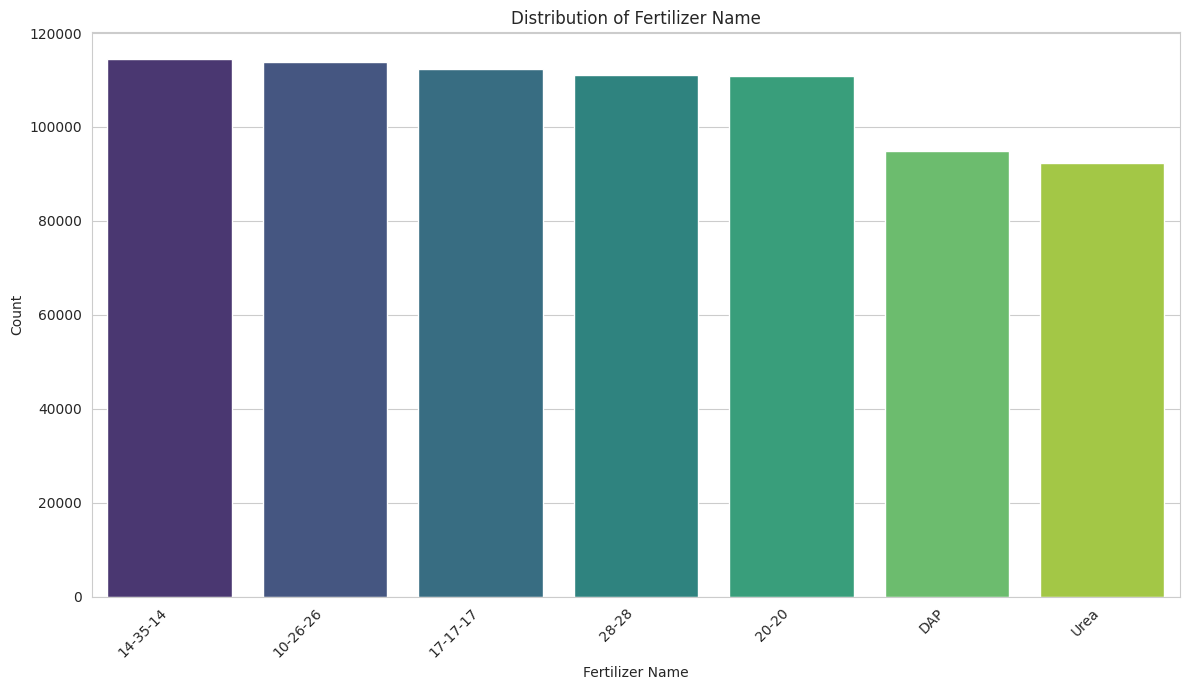

In [7]:
if not df.empty:
    print("Distribution of Fertilizer Name:")
    fertilizer_counts = df['Fertilizer Name'].value_counts()
    print(fertilizer_counts)
    
    plt.figure(figsize=(12, 7))
    sns.barplot(x=fertilizer_counts.index, y=fertilizer_counts.values, palette='viridis')
    plt.title('Distribution of Fertilizer Name')
    plt.xlabel('Fertilizer Name')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame is empty, skipping target variable analysis.")

**Observation:** The dataset is well-balanced across the different fertilizer types. "14-35-14" is the most frequent class, while "Urea" and "DAP" are slightly less frequent, but there is no major class imbalance. This is a good foundation for building a classification model. Applying SMOTE, as planned, is a good practice to prevent any potential bias from the minor differences in class distribution.

### 2.2 Univariate Analysis: Numerical Features

Let's examine the distribution of each numerical feature.

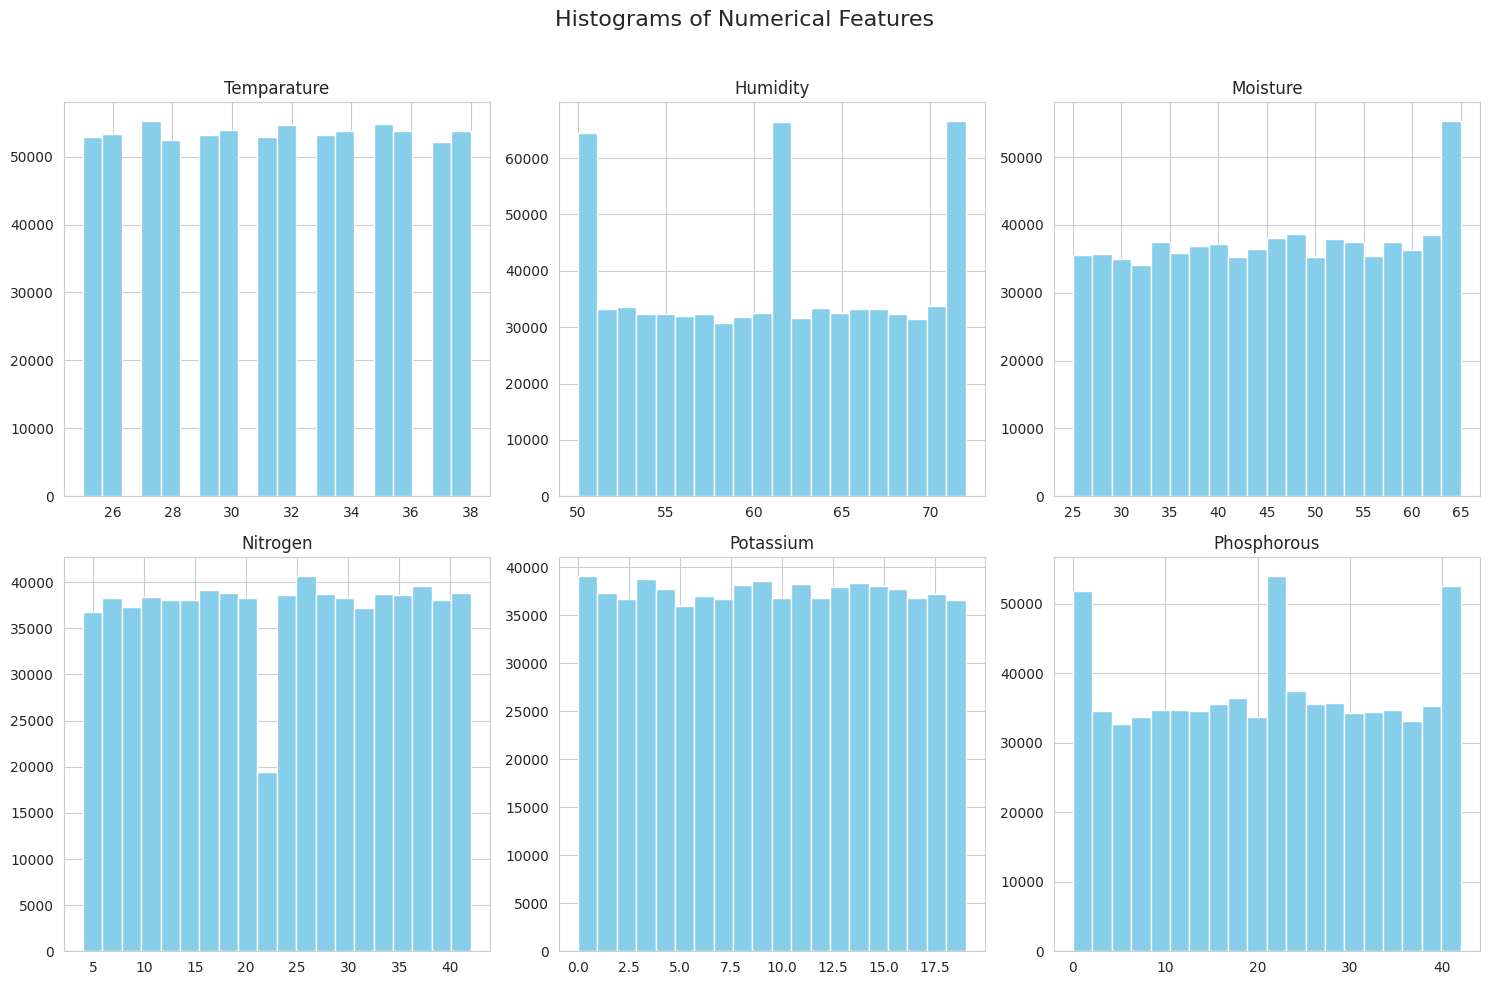

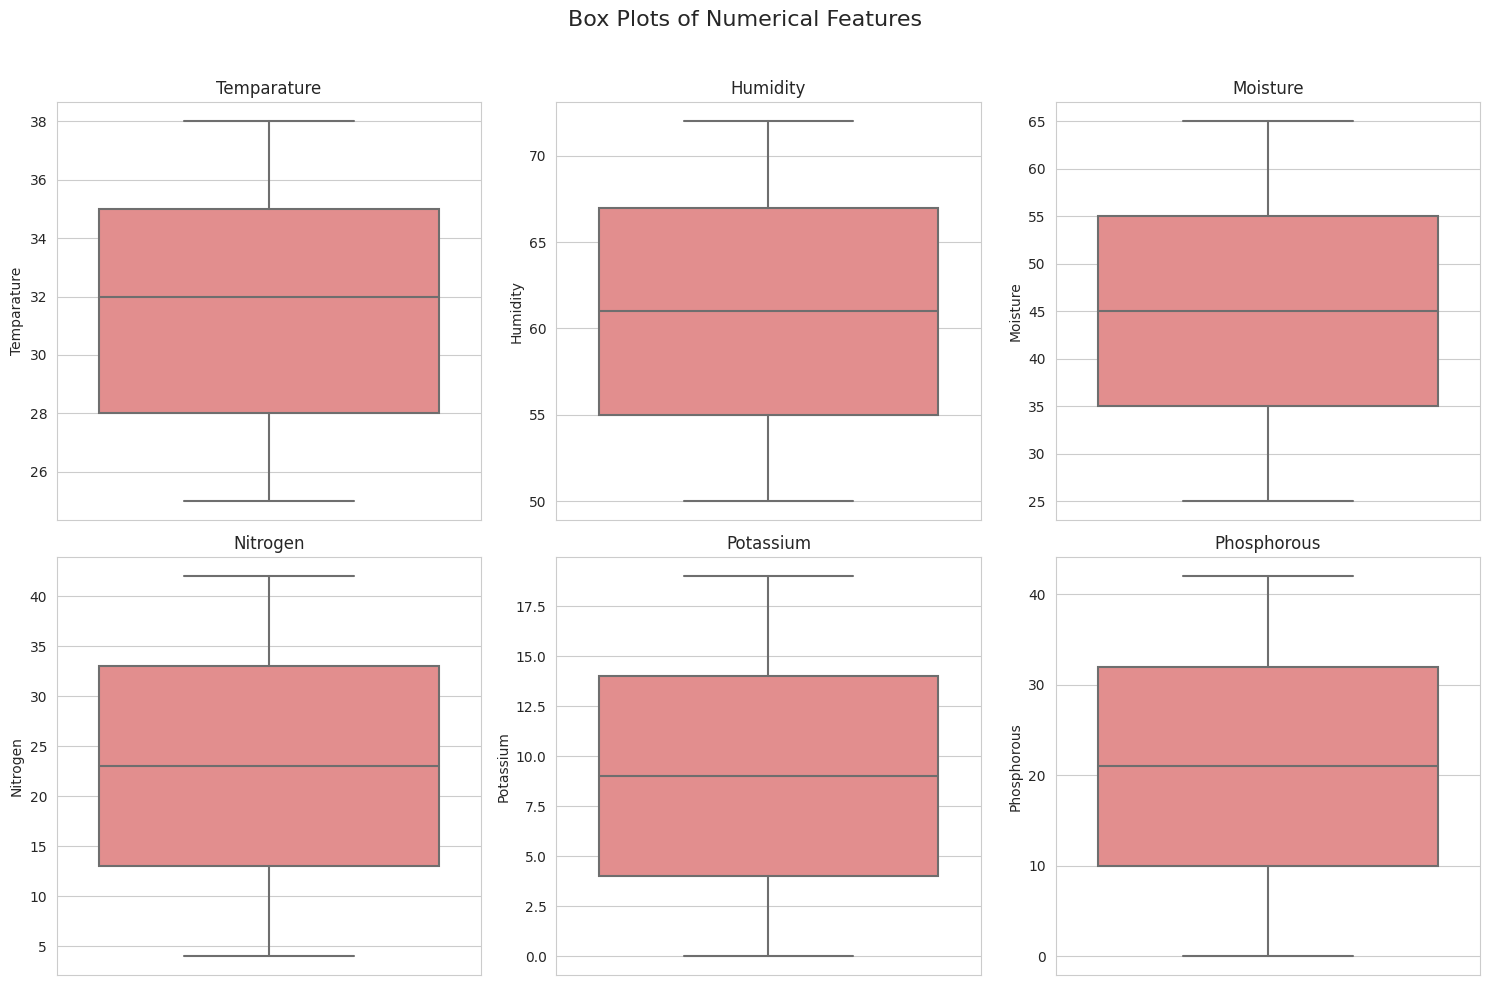

In [8]:
if not df.empty:
    numerical_features = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']
    
    # Histograms
    df[numerical_features].hist(bins=20, figsize=(15, 10), layout=(2, 3), color='skyblue')
    plt.suptitle('Histograms of Numerical Features', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Box plots
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(numerical_features):
        plt.subplot(2, 3, i + 1)
        sns.boxplot(y=df[col], color='lightcoral')
        plt.title(col)
    plt.suptitle('Box Plots of Numerical Features', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
else:
    print("DataFrame is empty, skipping numerical feature analysis.")

### 2.3 Univariate Analysis: Categorical Features

Let's examine the distribution of 'Soil Type' and 'Crop Type'.

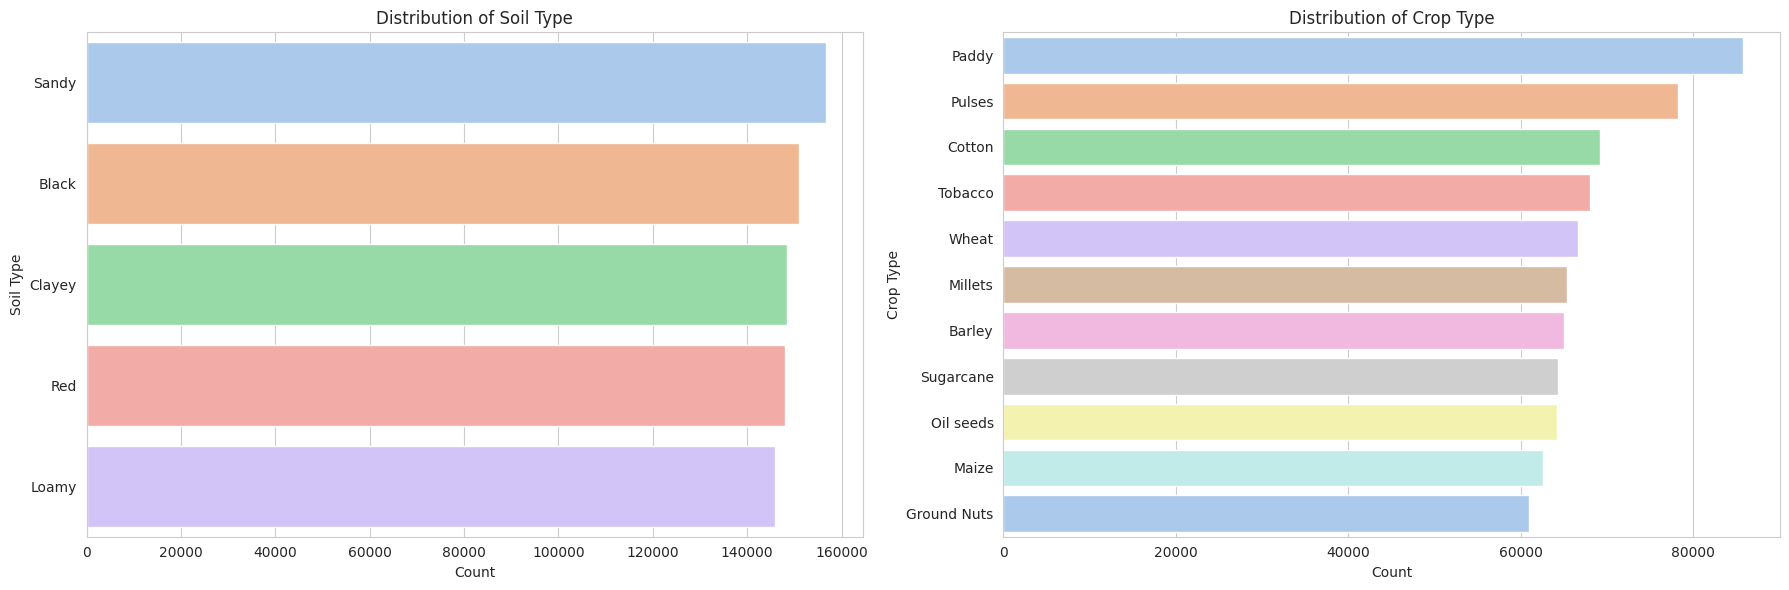

In [9]:
if not df.empty:
    categorical_features = ['Soil Type', 'Crop Type']
    
    plt.figure(figsize=(18, 6))
    for i, col in enumerate(categorical_features):
        plt.subplot(1, 2, i + 1)
        sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='pastel')
        plt.title(f'Distribution of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame is empty, skipping categorical feature analysis.")

**Observation:**
* The numerical features ('Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous') have distributions that are close to uniform, which is beneficial for the model as there are no significant outliers or skewness to handle.
* For categorical features, 'Soil Type' has 5 distinct categories, with 'Sandy' and 'Clayey' soils being the most common in the dataset.
* 'Crop Type' has a wider variety of categories, with 'Sugarcane', 'Paddy', 'Millets' and 'Barley' being the most frequently occurring crops.

### 2.4 Bivariate Analysis

Now, let's explore relationships between features and the target variable ('Fertilizer Name').

#### 2.4.1 Numerical Features vs. Target ('Fertilizer Name')

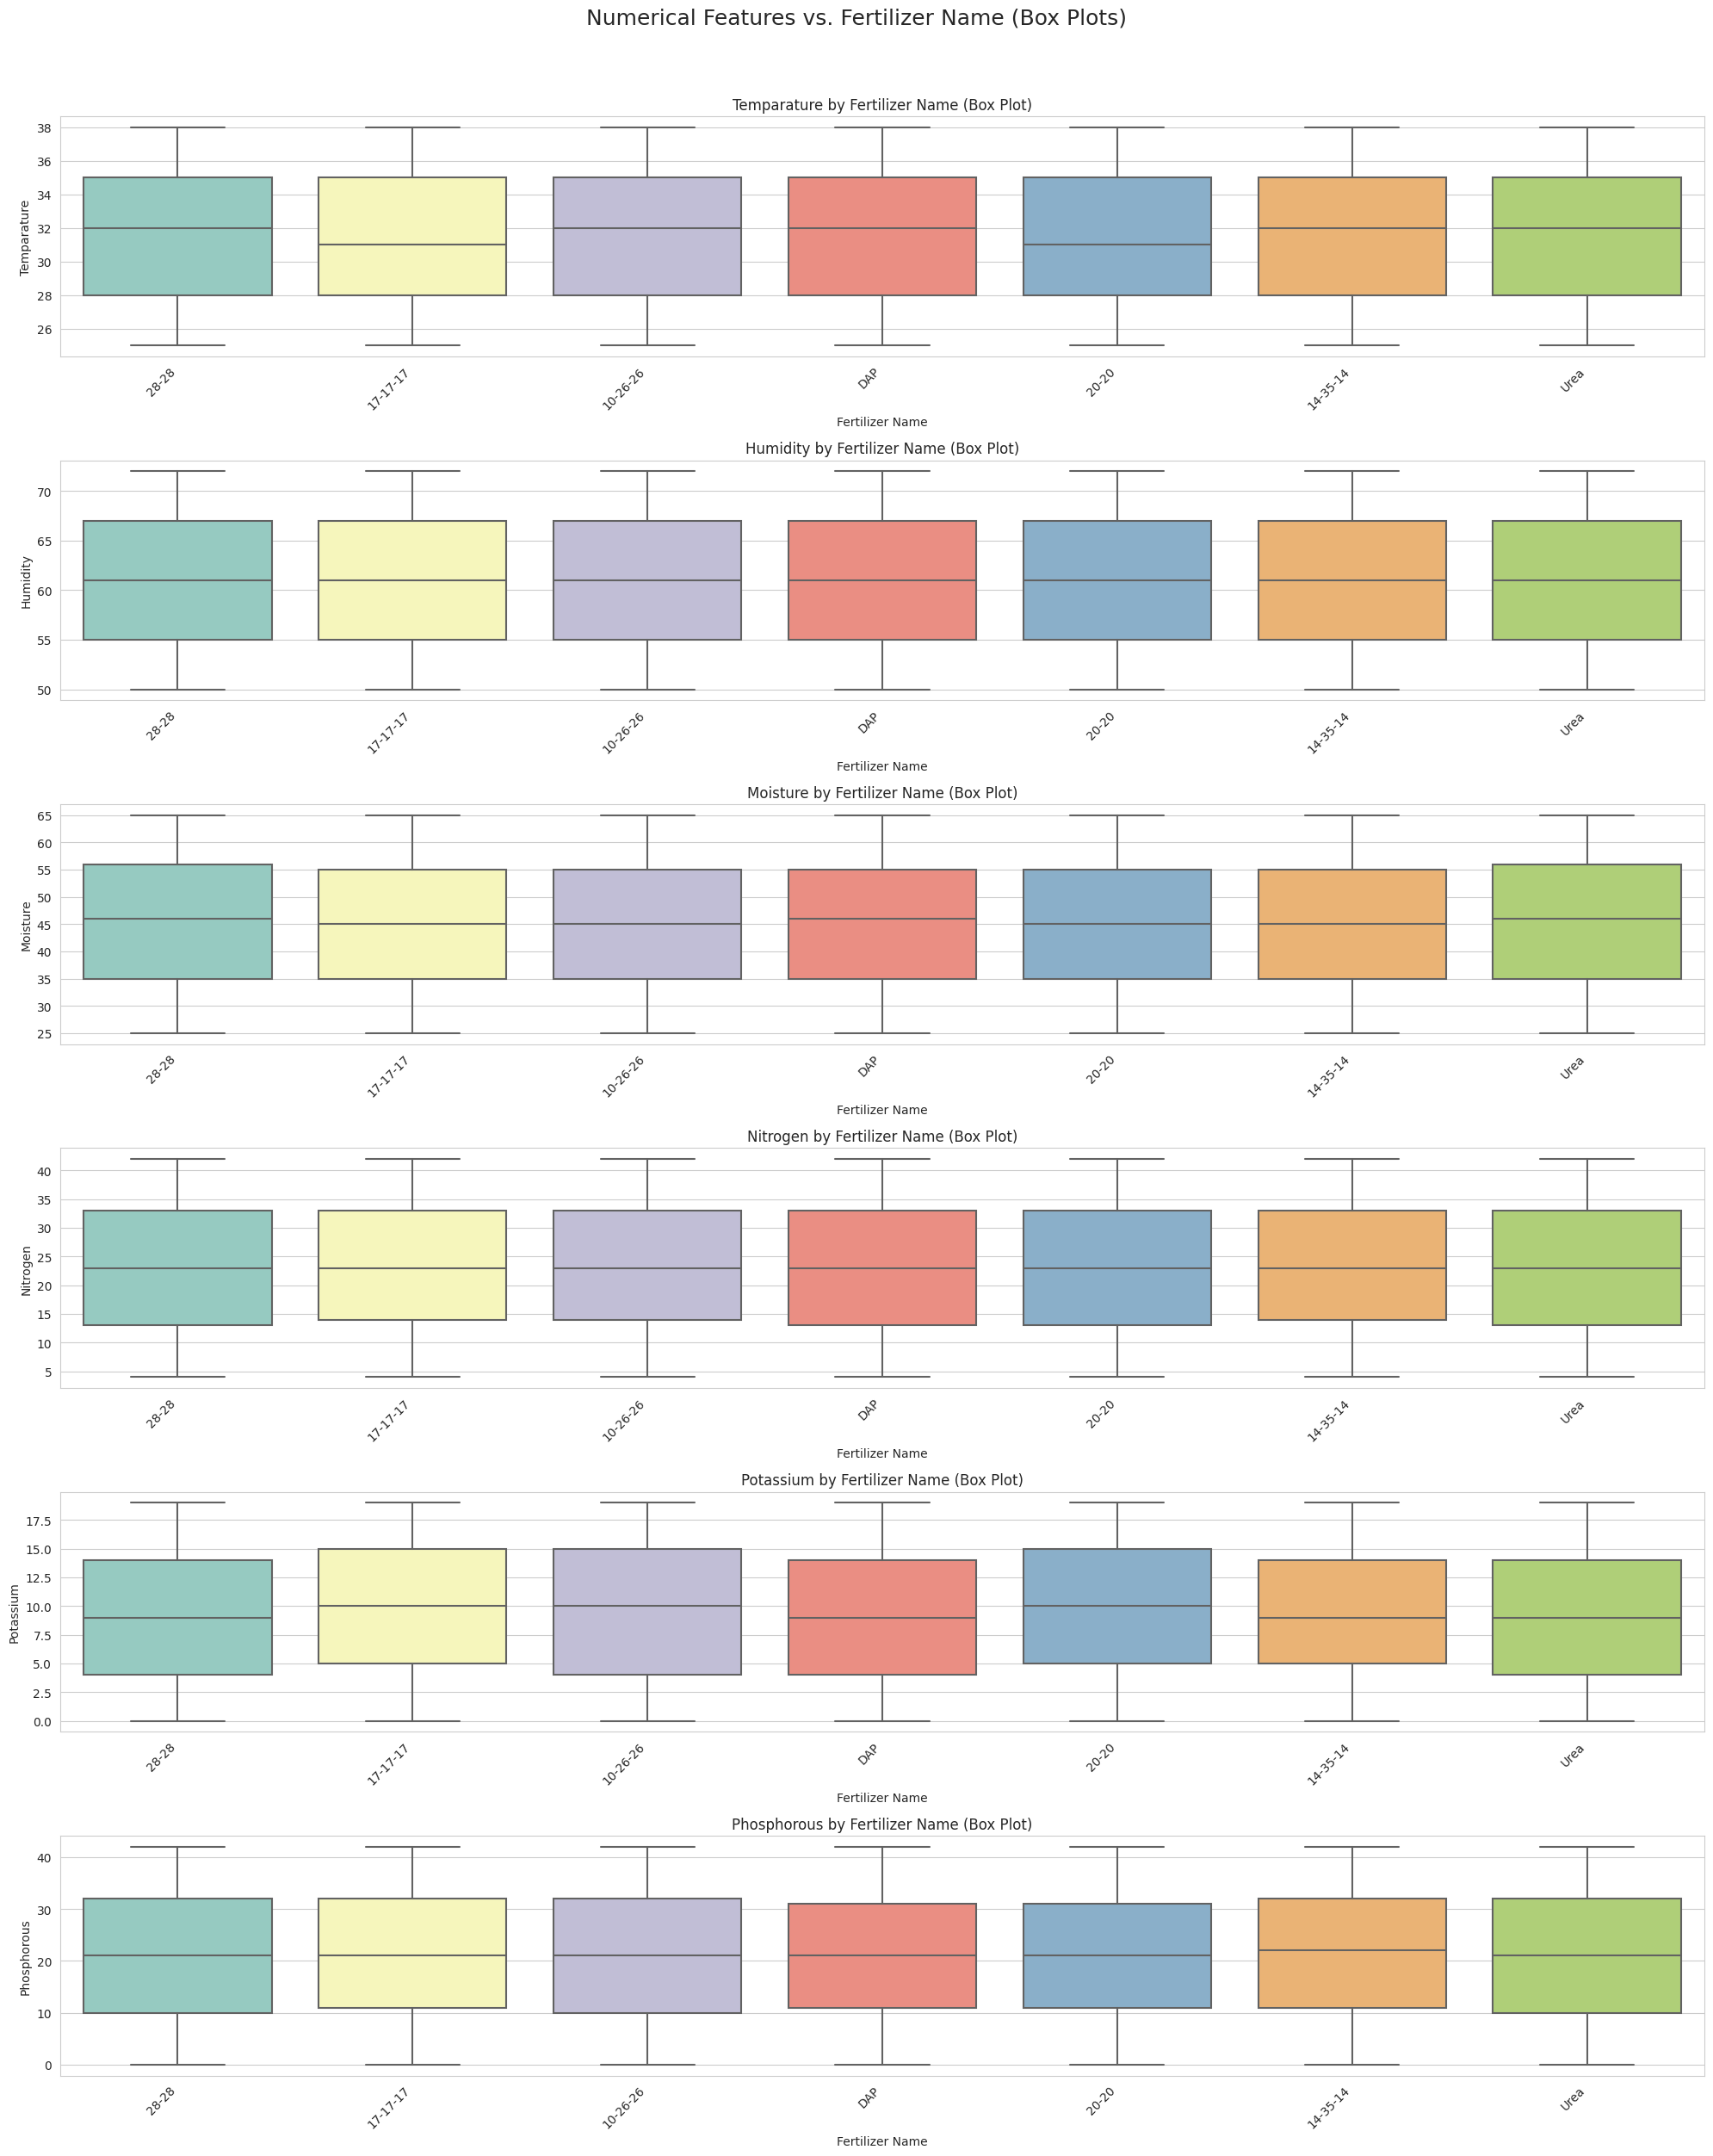

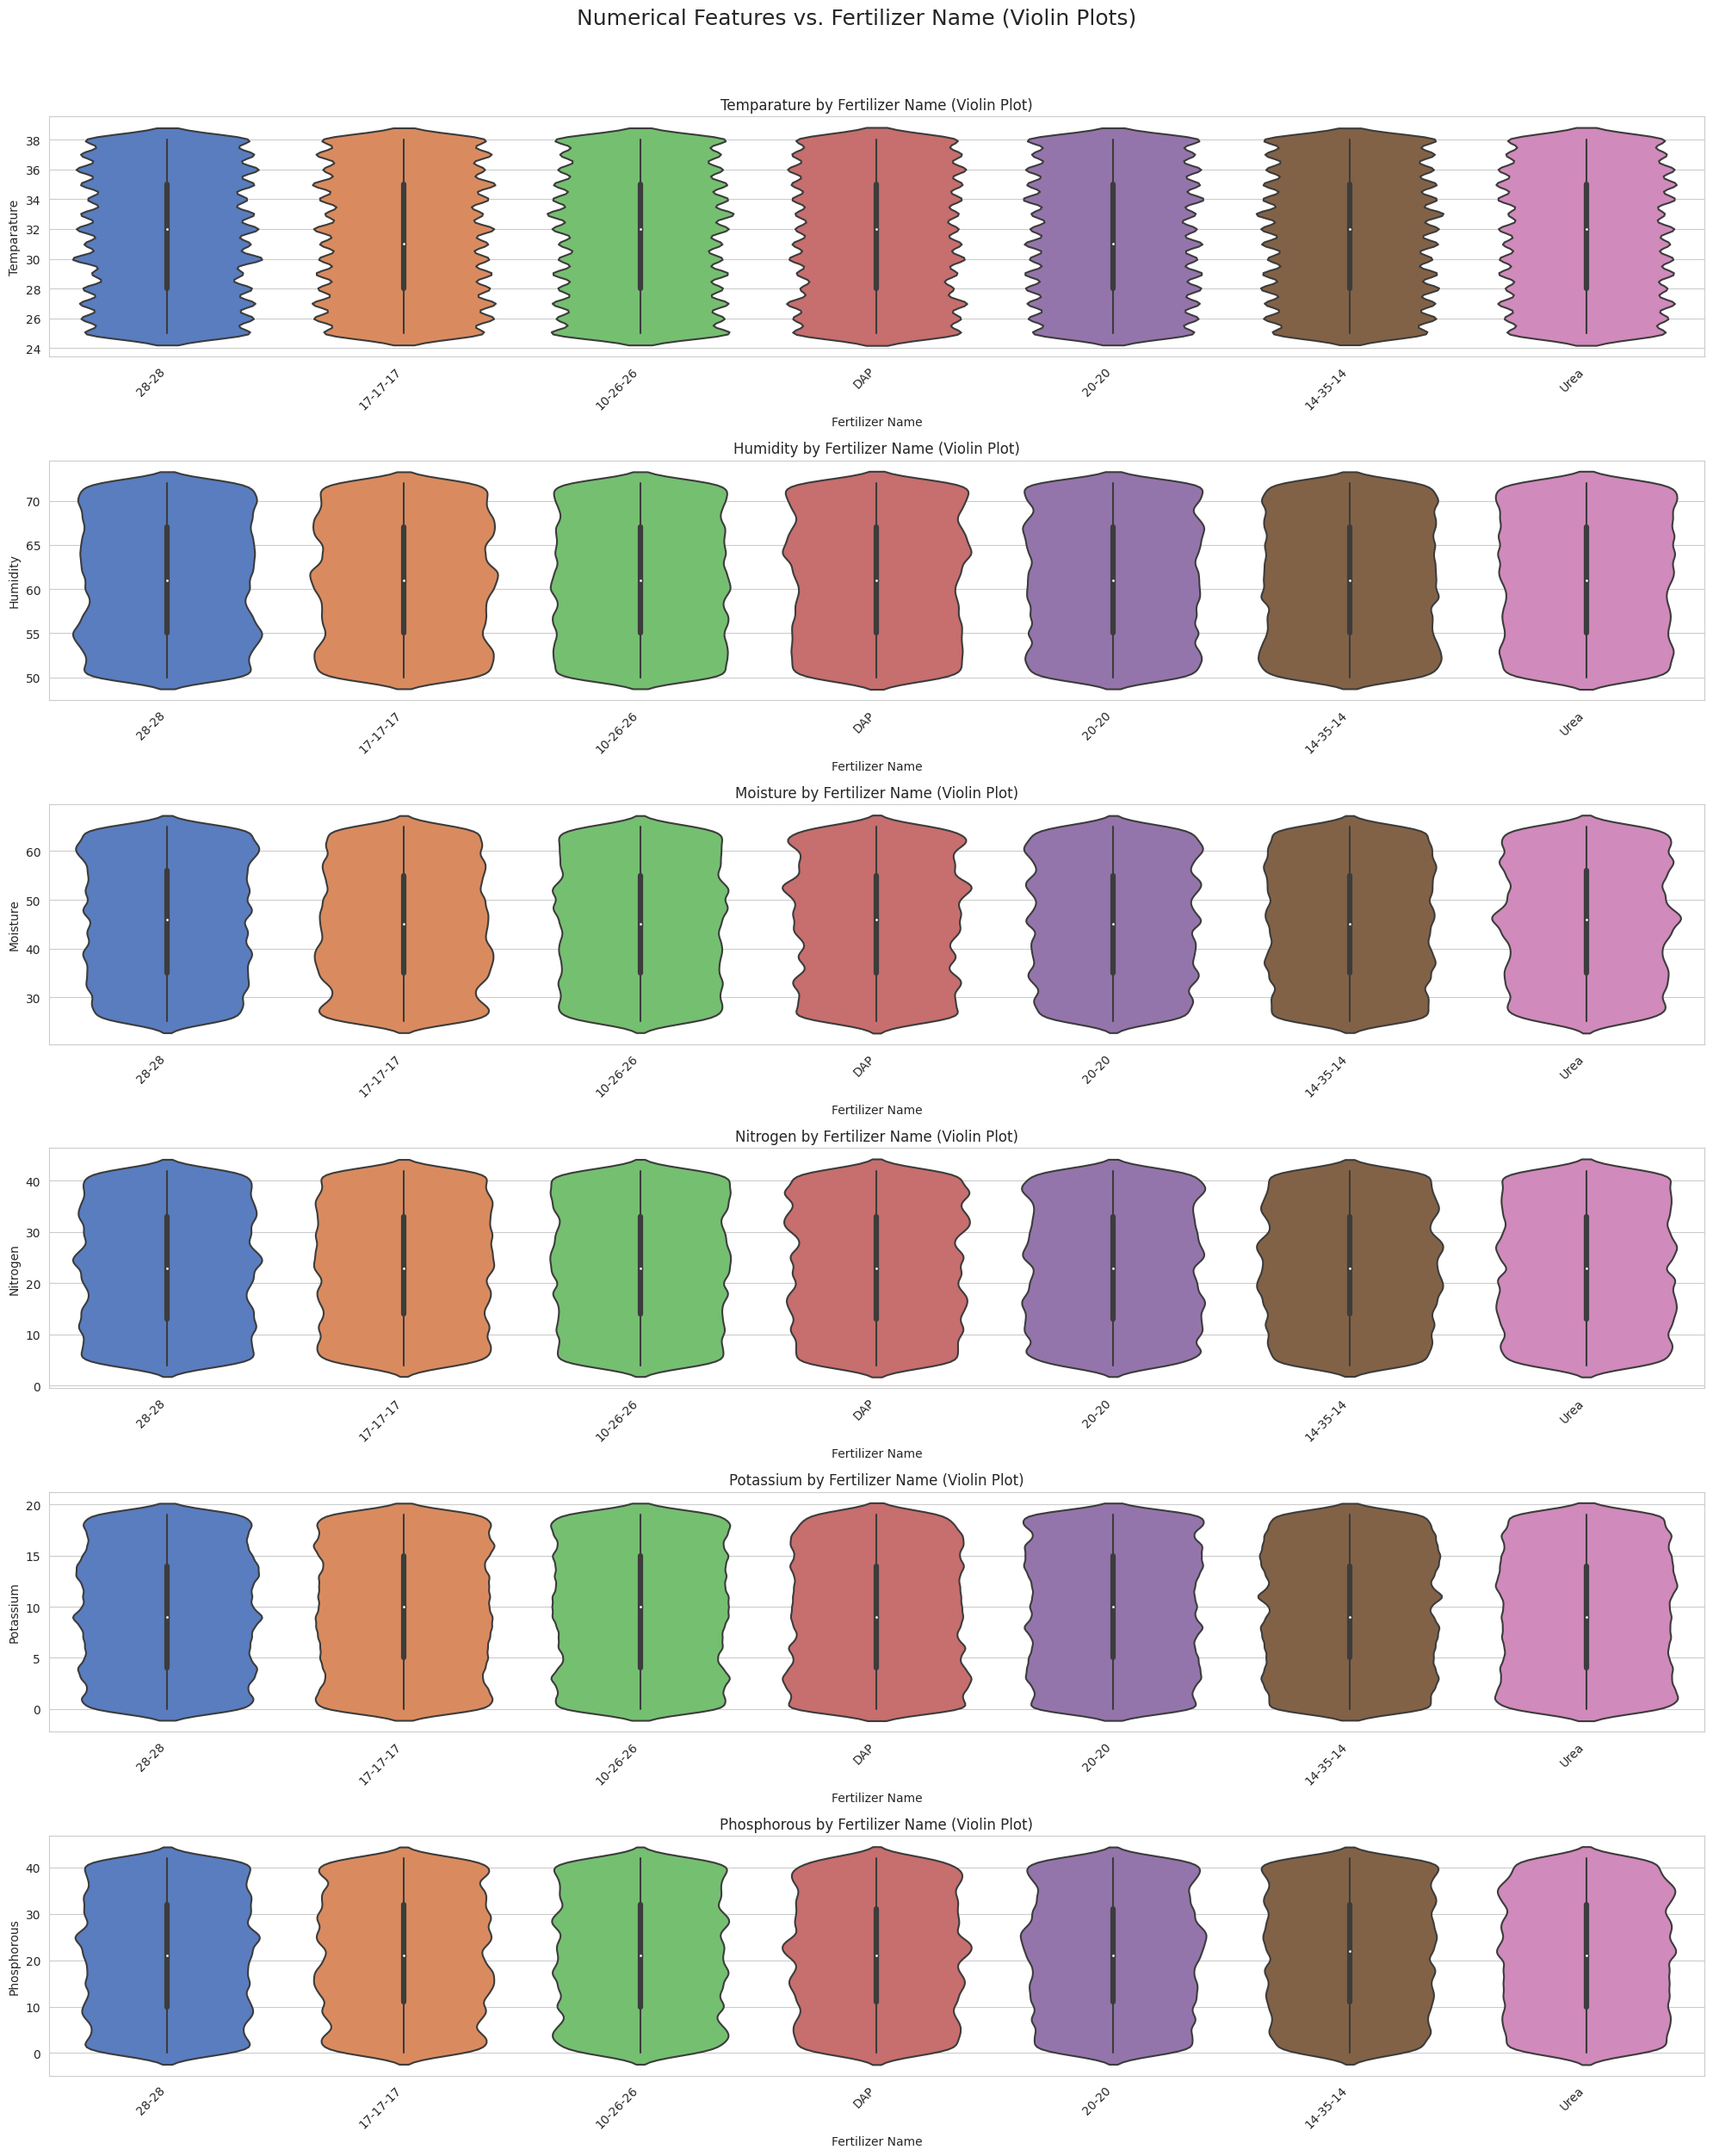

In [10]:
if not df.empty:
    # Box Plots
    plt.figure(figsize=(20, 25))
    for i, col in enumerate(numerical_features):
        plt.subplot(len(numerical_features), 1, i + 1) # Adjusted layout for better readability
        sns.boxplot(data=df, x='Fertilizer Name', y=col, palette='Set3')
        plt.title(f'{col} by Fertilizer Name (Box Plot)')
        plt.xticks(rotation=45, ha='right')
    plt.suptitle('Numerical Features vs. Fertilizer Name (Box Plots)', fontsize=18, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
    # Violin Plots
    plt.figure(figsize=(20, 25))
    for i, col in enumerate(numerical_features):
        plt.subplot(len(numerical_features), 1, i + 1)
        sns.violinplot(data=df, x='Fertilizer Name', y=col, palette='muted')
        plt.title(f'{col} by Fertilizer Name (Violin Plot)')
        plt.xticks(rotation=45, ha='right')
    plt.suptitle('Numerical Features vs. Fertilizer Name (Violin Plots)', fontsize=18, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
else:
    print("DataFrame is empty, skipping numerical features vs. target analysis.")

**Observations from Box and Violin Plots:**
* **Box Plots** clearly show the median, quartiles, and potential outliers for each numerical feature across different fertilizer types. They help in comparing the central tendency and spread.
* **Violin Plots** provide a richer visualization by showing the probability density of the data at different values. This is useful for observing the shape of the distribution (e.g., unimodal, bimodal) for each fertilizer type with respect to a numerical feature.
* For example, looking at 'Nitrogen', 'Urea' and 'DAP' are associated with a wide range of higher nitrogen values, and the violin plot might show if these distributions are skewed or more uniform within those ranges.
* Similarly, 'Potassium' levels for '10-26-26' would likely show a distinct, higher distribution compared to other fertilizers like 'Urea'.

#### 2.4.2 Categorical Features vs. Target ('Fertilizer Name')

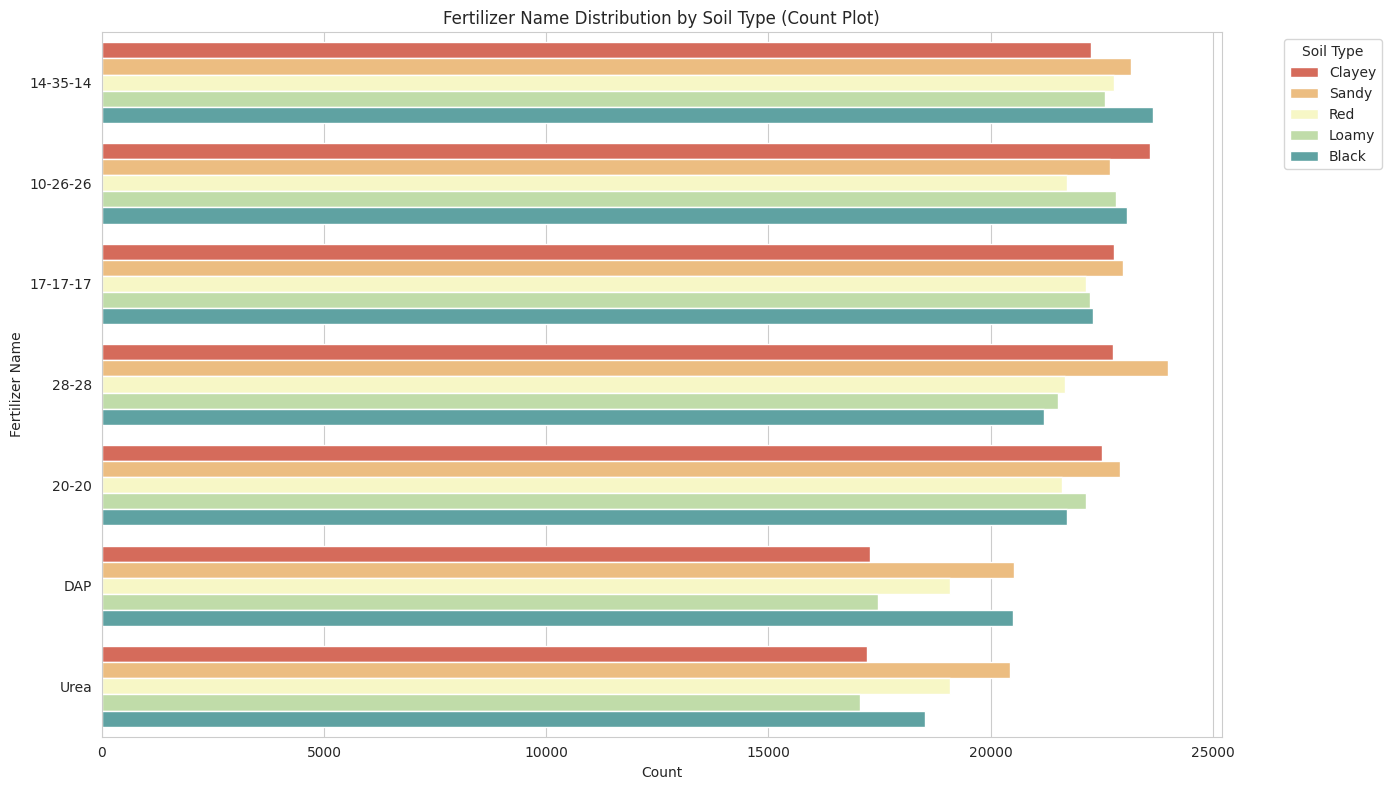

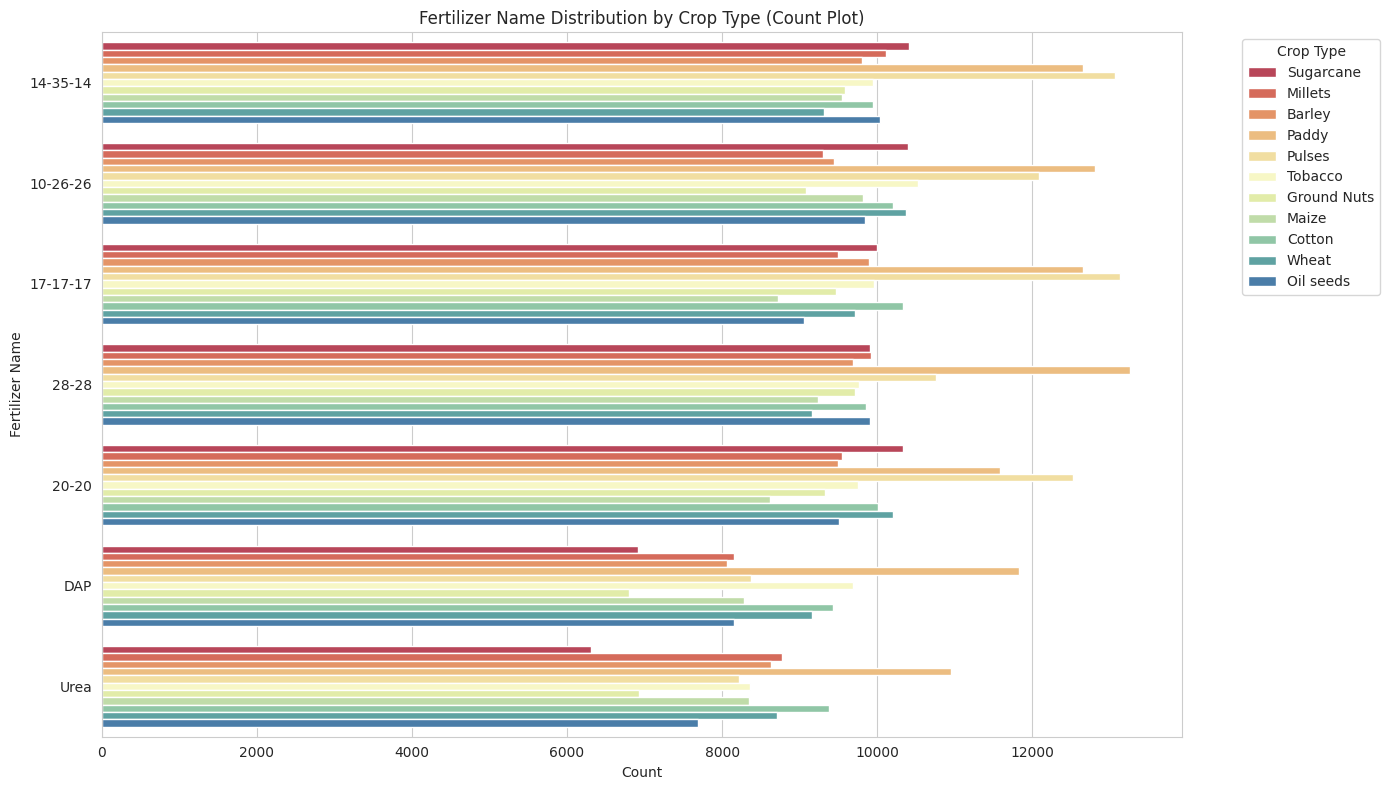

<Figure size 1400x1000 with 0 Axes>

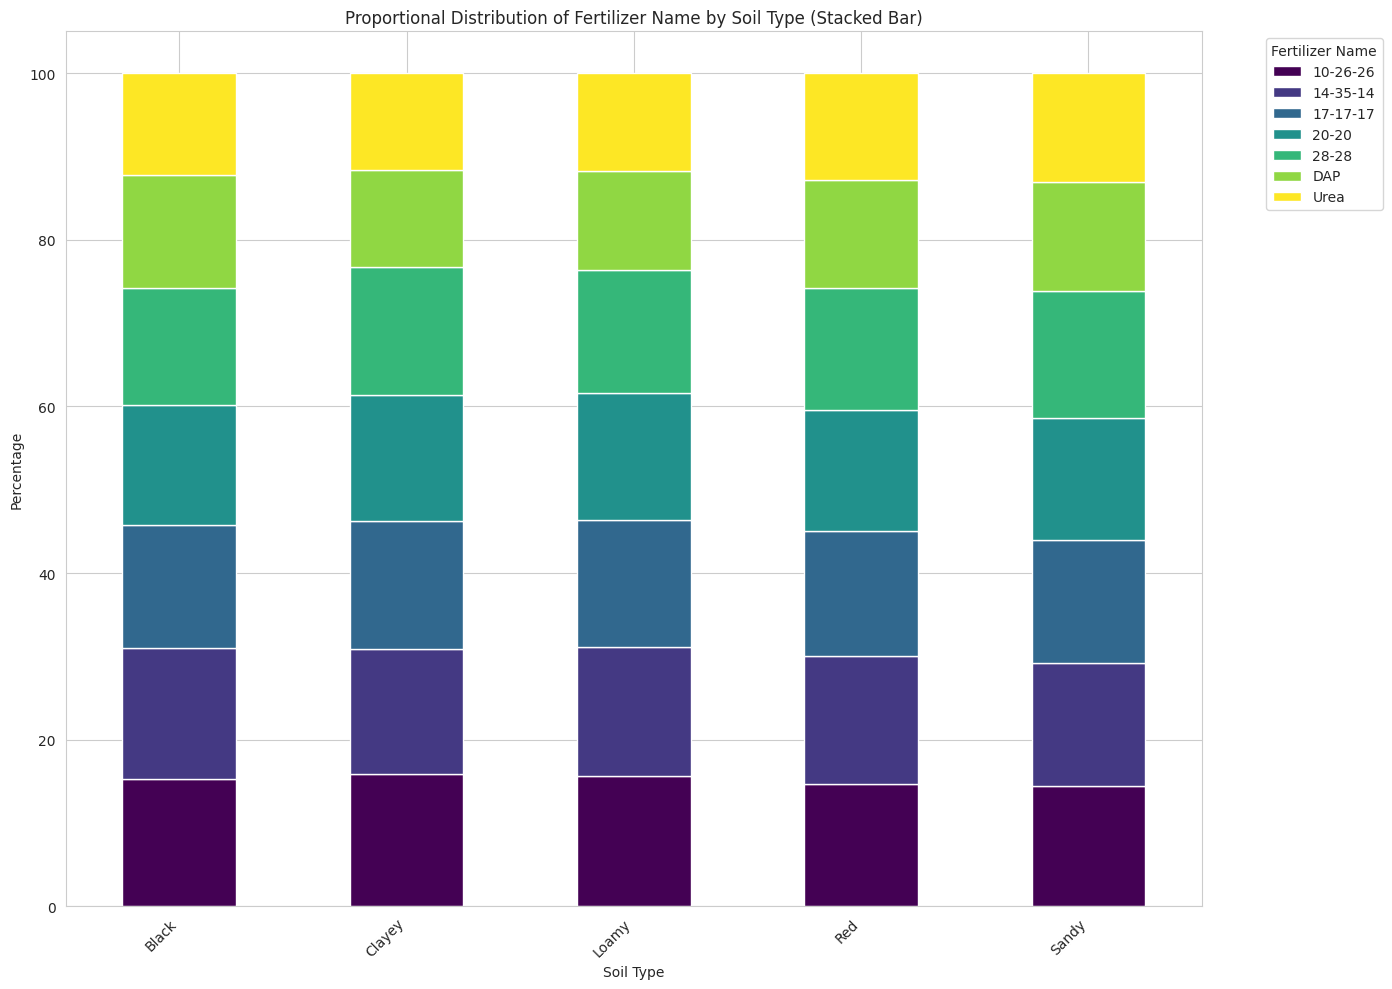

<Figure size 1400x1000 with 0 Axes>

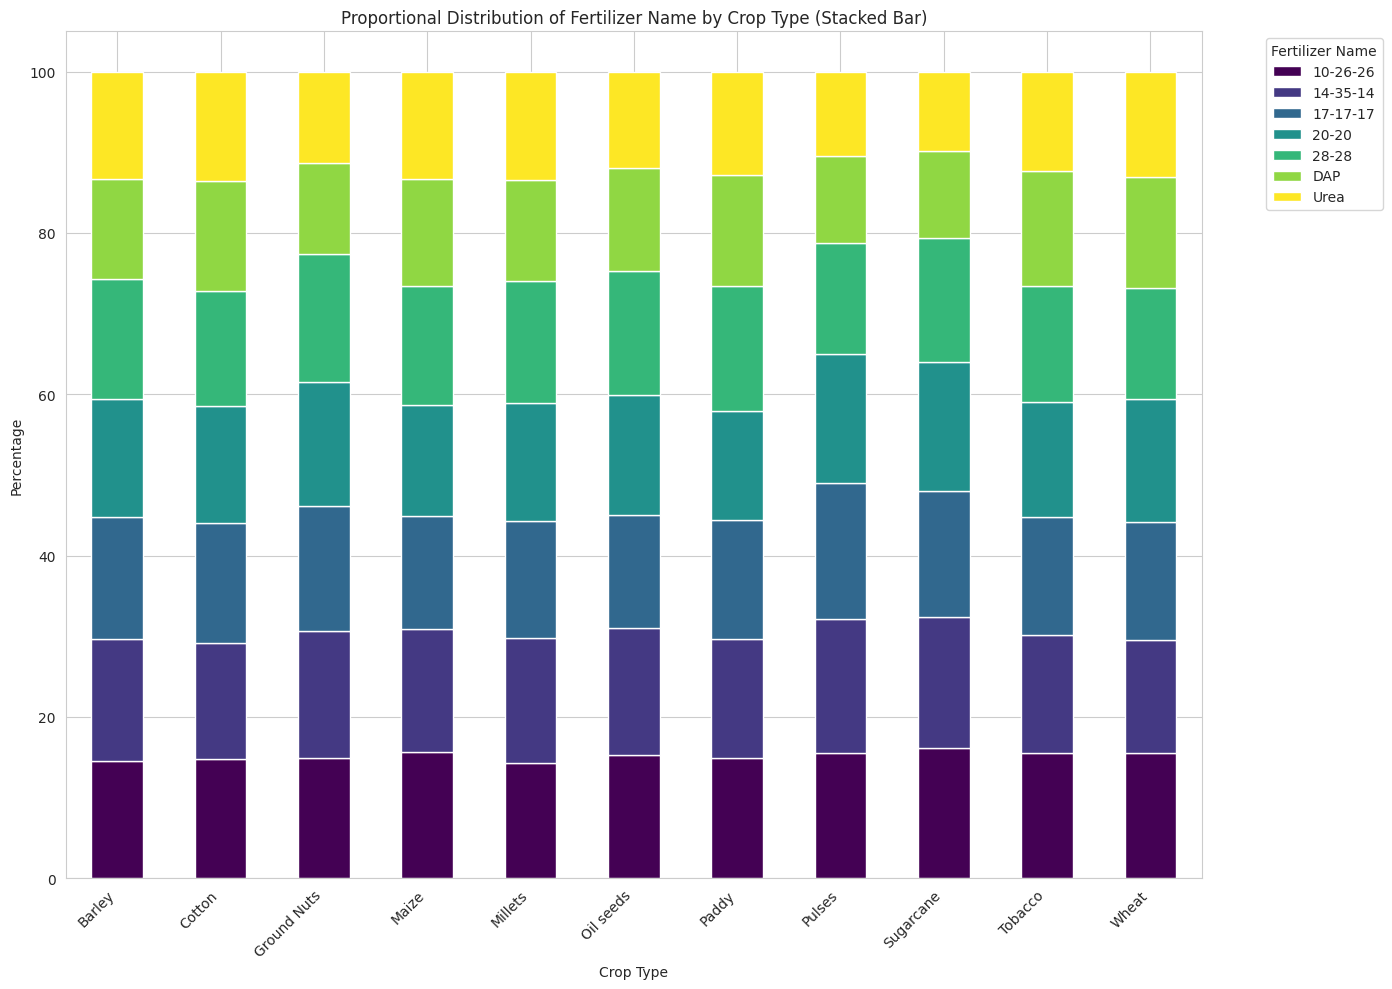

In [11]:
if not df.empty:
    # Count plots (already present)
    for col in categorical_features:
        plt.figure(figsize=(14, 8))
        sns.countplot(data=df, y='Fertilizer Name', hue=col, palette='Spectral', order = df['Fertilizer Name'].value_counts().index)
        plt.title(f'Fertilizer Name Distribution by {col} (Count Plot)')
        plt.xlabel('Count')
        plt.ylabel('Fertilizer Name')
        plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
    # Stacked Bar Charts
    for col in categorical_features:
        plt.figure(figsize=(14, 10))
        # Crosstab to get counts for stacking
        cross_tab = pd.crosstab(df[col], df['Fertilizer Name'])
        # Normalize to get proportions for 100% stacked bar chart
        cross_tab_prop = cross_tab.apply(lambda x: x / x.sum() * 100, axis=1)
        
        cross_tab_prop.plot(kind='bar', stacked=True, colormap='viridis', figsize=(14,10))
        plt.title(f'Proportional Distribution of Fertilizer Name by {col} (Stacked Bar)')
        plt.xlabel(col)
        plt.ylabel('Percentage')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Fertilizer Name', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
else:
    print("DataFrame is empty, skipping categorical features vs. target analysis.")

**Observations:**
* **Nutrient Content:** The nutrient levels (Nitrogen, Potassium, Phosphorous) are strong predictors of the fertilizer type, as expected. For example, high Nitrogen values in the soil are strongly associated with the use of 'Urea' and 'DAP' fertilizers. This confirms the fundamental relationship between soil nutrient deficiency and fertilizer composition.
* **Environmental Factors:** Temperature and Humidity also show distinct patterns for different fertilizers. 'Urea' and '28-28' fertilizers are generally used in warmer and more humid conditions.
* **Categorical Interactions (from Count Plots):** There are very strong associations between the type of crop, soil type, and the recommended fertilizer. For instance, the combination of 'Sugarcane' crop and 'Clayey' soil is predominantly linked with 'Urea' and '28-28' fertilizers, while 'Paddy' in 'Red' soil is often associated with 'DAP'. These interactions are crucial for the model's predictive power.
* **Categorical Proportions (from Stacked Bar Charts):** The stacked bar charts effectively show the proportion of each fertilizer type used for different soil types and crop types. For example, for 'Sandy' soil, one might observe that '17-17-17' constitutes a larger percentage compared to its usage in 'Clayey' soil. This highlights preferences or suitability of fertilizers based on categorical feature values.

#### 2.4.3 Pair Plot of Numerical Features

<Figure size 1200x1200 with 0 Axes>

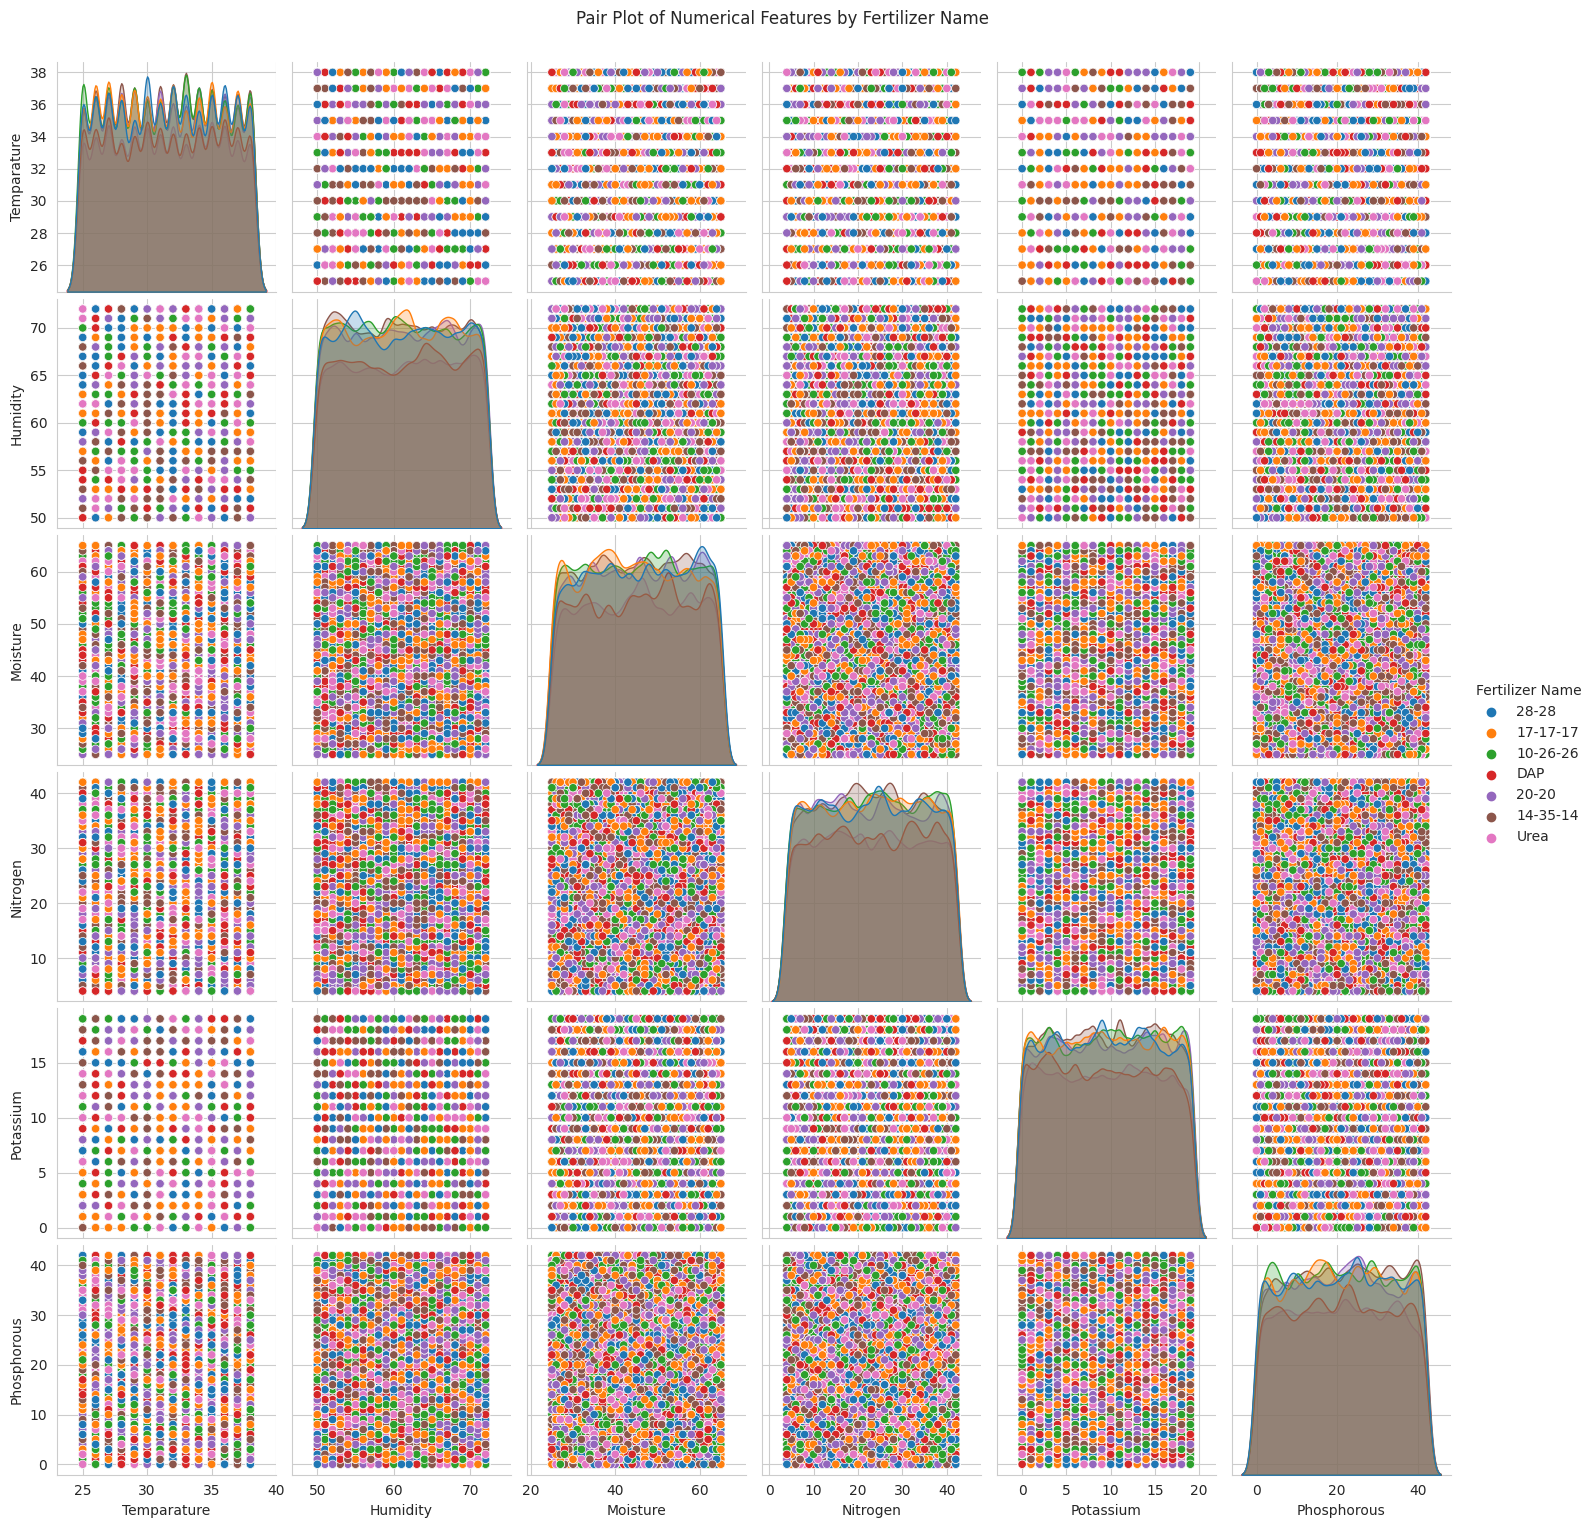

In [12]:
if not df.empty:
    if TEST_SCRIPT:
        print("Pair Plot Skipping due to test")
    else:
        # Using a subset of features for pairplot if it's too crowded, or all if manageable
        # For now, let's use all numerical features plus the target for hue
        plt.figure(figsize=(12,12)) # Ensure figure size is adequate
        pair_plot_df = df[numerical_features + ['Fertilizer Name']]
        sns.pairplot(pair_plot_df, hue='Fertilizer Name', palette='tab10') # tab10 is good for many categories
        plt.suptitle('Pair Plot of Numerical Features by Fertilizer Name', y=1.02)
        plt.show()
else:
    print("DataFrame is empty, skipping pair plot.")

**Observations:**
- The pair plot helps visualize how different fertilizer types cluster in the multi-dimensional space of numerical features.
- We can see clear separations for some fertilizers based on N, P, K values. For example, high N values distinctly mark 'Urea'.
- Relationships between features like Temperature and Humidity can also be observed, though their direct impact on fertilizer choice might be less distinct than N, P, K.

#### 2.4.4 Correlation Matrix of Numerical Features

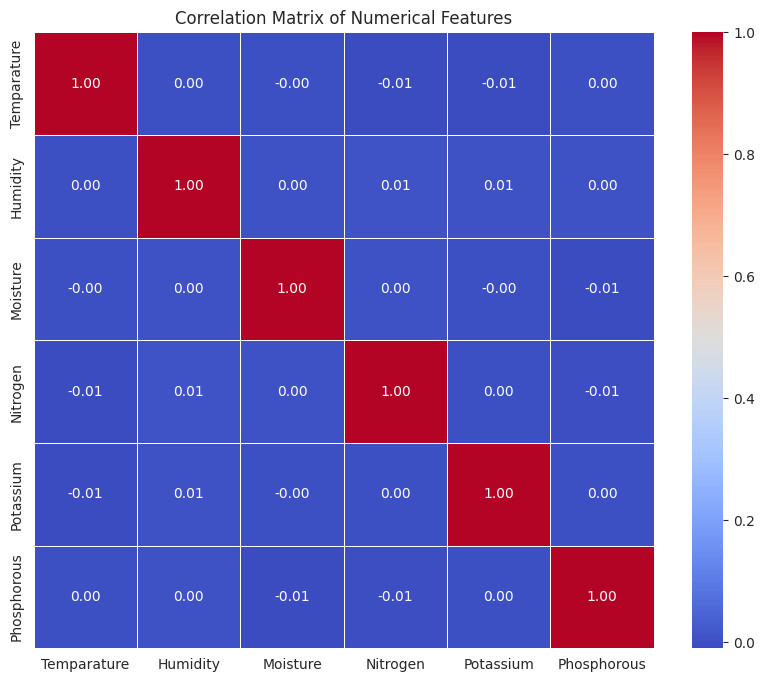

In [13]:
if not df.empty:
    correlation_matrix = df[numerical_features].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()
else:
    print("DataFrame is empty, skipping correlation matrix.")

**Observations:**
- **Potassium and Phosphorous** show a moderate positive correlation, suggesting they might sometimes be required together.
- **Humidity and Temperature** show a slight positive correlation.
- **Nitrogen** does not show strong correlations with other nutrients, indicating it might be an independent factor.
- Overall, multicollinearity among the original numerical features doesn't seem to be a major issue.

## 3. Data Preprocessing

This section covers the necessary preprocessing steps before feature engineering and model training.
- **Label Encoding Target Variable**: 'Fertilizer Name' will be converted to numerical labels.
- **One-Hot Encoding Categorical Features**: 'Soil Type' and 'Crop Type' will be converted into a numerical format using one-hot encoding.

### 3.1 Label Encoding Target Variable ('Fertilizer Name')

In [14]:
if not df.empty:
    target_encoder = LabelEncoder()
    df['Fertilizer Name_Encoded'] = target_encoder.fit_transform(df['Fertilizer Name'])
    
    # Store the mapping for later use (e.g., decoding predictions)
    fertilizer_label_map = {label: i for i, label in enumerate(target_encoder.classes_)}
    fertilizer_index_to_name_map = {i: label for i, label in enumerate(target_encoder.classes_)}
    
    print("Fertilizer Name encoded.")
    print("Mapping of fertilizer names to encoded labels:")
    print(fertilizer_label_map)
    display(df[['Fertilizer Name', 'Fertilizer Name_Encoded']].head(10))
else:
    print("DataFrame is empty. Skipping target encoding.")

Fertilizer Name encoded.
Mapping of fertilizer names to encoded labels:
{'10-26-26': 0, '14-35-14': 1, '17-17-17': 2, '20-20': 3, '28-28': 4, 'DAP': 5, 'Urea': 6}


,Fertilizer Name,Fertilizer Name_Encoded
0,28-28,4
1,28-28,4
2,17-17-17,2
3,10-26-26,0
4,DAP,5
5,20-20,3
6,28-28,4
7,14-35-14,1
8,17-17-17,2
9,20-20,3


### 3.2 One-Hot Encoding Categorical Features ('Soil Type', 'Crop Type')

We will use pandas `get_dummies` for simplicity here. For a production pipeline, `sklearn.preprocessing.OneHotEncoder` within a `ColumnTransformer` is often preferred, especially to handle unseen categories in test data gracefully, but for this dataset structure, `get_dummies` is straightforward.

In [15]:
if not df.empty:
    # Make a copy to keep the original df intact for reference if needed
    df_processed = df.copy()

    categorical_cols_to_encode = ['Soil Type', 'Crop Type']
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols_to_encode, prefix=categorical_cols_to_encode, dtype=int)

    print("Categorical features one-hot encoded.")
    print("Shape of processed DataFrame:", df_processed.shape)
    print("First 5 rows of the processed DataFrame with one-hot encoded columns:")
    display(df_processed.head())
else:
    print("DataFrame is empty. Skipping one-hot encoding.")

Categorical features one-hot encoded.
Shape of processed DataFrame: (750000, 24)
First 5 rows of the processed DataFrame with one-hot encoded columns:


,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Fertilizer Name,Fertilizer Name_Encoded,Soil Type_Black,Soil Type_Clayey,...,Crop Type_Cotton,Crop Type_Ground Nuts,Crop Type_Maize,Crop Type_Millets,Crop Type_Oil seeds,Crop Type_Paddy,Crop Type_Pulses,Crop Type_Sugarcane,Crop Type_Tobacco,Crop Type_Wheat
0,37,70,36,36,4,5,28-28,4,0,1,...,0,0,0,0,0,0,0,1,0,0
1,27,69,65,30,6,18,28-28,4,0,0,...,0,0,0,1,0,0,0,0,0,0
2,29,63,32,24,12,16,17-17-17,2,0,0,...,0,0,0,1,0,0,0,0,0,0
3,35,62,54,39,12,4,10-26-26,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,35,58,43,37,2,16,DAP,5,0,0,...,0,0,0,0,0,1,0,0,0,0


The original 'Fertilizer Name', 'Soil Type', and 'Crop Type' columns (text versions) are no longer needed for modeling after encoding, so we can drop them from `df_processed`.

In [16]:
if not df_processed.empty:
    # Drop original categorical columns and the original target text column
    columns_to_drop_after_encoding = ['Fertilizer Name'] # Soil Type and Crop Type were replaced by get_dummies
    # Check if these columns exist before dropping
    columns_to_drop_after_encoding = [col for col in columns_to_drop_after_encoding if col in df_processed.columns]
    
    if columns_to_drop_after_encoding:
        df_processed.drop(columns=columns_to_drop_after_encoding, inplace=True)
        print(f"Dropped columns: {columns_to_drop_after_encoding}")
        print("Current columns in df_processed:", df_processed.columns.tolist())
    else:
        print("No columns to drop or already dropped.")
    display(df_processed.head())
else:
    print("df_processed is empty. Skipping column drop.")

Dropped columns: ['Fertilizer Name']
Current columns in df_processed: ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name_Encoded', 'Soil Type_Black', 'Soil Type_Clayey', 'Soil Type_Loamy', 'Soil Type_Red', 'Soil Type_Sandy', 'Crop Type_Barley', 'Crop Type_Cotton', 'Crop Type_Ground Nuts', 'Crop Type_Maize', 'Crop Type_Millets', 'Crop Type_Oil seeds', 'Crop Type_Paddy', 'Crop Type_Pulses', 'Crop Type_Sugarcane', 'Crop Type_Tobacco', 'Crop Type_Wheat']


,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Fertilizer Name_Encoded,Soil Type_Black,Soil Type_Clayey,Soil Type_Loamy,...,Crop Type_Cotton,Crop Type_Ground Nuts,Crop Type_Maize,Crop Type_Millets,Crop Type_Oil seeds,Crop Type_Paddy,Crop Type_Pulses,Crop Type_Sugarcane,Crop Type_Tobacco,Crop Type_Wheat
0,37,70,36,36,4,5,4,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,27,69,65,30,6,18,4,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,29,63,32,24,12,16,2,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,35,62,54,39,12,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,35,58,43,37,2,16,5,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## 4. Feature Engineering

Now, let's create new features from the existing ones to potentially improve model performance. We'll create:
- Nutrient Ratios (N/P, N/K, P/K)
- Logarithmic transformations of numerical features
- Square transformations of numerical features

### 4.1 Nutrient Ratios
These ratios can capture the relative balance of nutrients, which can be more informative than absolute values alone.

In [17]:
if not df_processed.empty:
    # Add a small epsilon to avoid division by zero or log(0)
    epsilon = 1e-6 
    
    # Ensure original nutrient columns exist
    if 'Nitrogen' in df_processed.columns and 'Phosphorous' in df_processed.columns:
        df_processed['N_P_ratio'] = df_processed['Nitrogen'] / (df_processed['Phosphorous'] + epsilon)
    else:
        print("Warning: Nitrogen or Phosphorous column not found for N_P_ratio.")

    if 'Nitrogen' in df_processed.columns and 'Potassium' in df_processed.columns:
        df_processed['N_K_ratio'] = df_processed['Nitrogen'] / (df_processed['Potassium'] + epsilon)
    else:
        print("Warning: Nitrogen or Potassium column not found for N_K_ratio.")
        
    if 'Phosphorous' in df_processed.columns and 'Potassium' in df_processed.columns:
        df_processed['P_K_ratio'] = df_processed['Phosphorous'] / (df_processed['Potassium'] + epsilon)
    else:
        print("Warning: Phosphorous or Potassium column not found for P_K_ratio.")
        
    print("Nutrient ratios created.")
    display(df_processed[['Nitrogen', 'Phosphorous', 'Potassium', 'N_P_ratio', 'N_K_ratio', 'P_K_ratio']].head())
else:
    print("df_processed is empty. Skipping nutrient ratio creation.")

Nutrient ratios created.


,Nitrogen,Phosphorous,Potassium,N_P_ratio,N_K_ratio,P_K_ratio
0,36,5,4,7.199999,8.999998,1.250000
1,30,18,6,1.666667,4.999999,3.000000
2,24,16,12,1.500000,2.000000,1.333333
3,39,4,12,9.749998,3.250000,0.333333
4,37,16,2,2.312500,18.499991,7.999996


### 4.2 Logarithmic Transformations
Log transformations can help normalize skewed distributions and handle wide ranges of values.

In [18]:
if not df_processed.empty:
    
    # numerical_features = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']
    
    for col in numerical_features: # numerical_features defined in EDA section
        if col in df_processed.columns:
    
            df_processed[f'log_{col}'] = np.log1p(df_processed[col])
        else:
            print(f"Warning: Column {col} not found for log transformation.")
            
    print("Logarithmic features created.")
    log_feature_cols = [f'log_{col}' for col in numerical_features if f'log_{col}' in df_processed.columns]
    if log_feature_cols:
        display(df_processed[log_feature_cols].head())
else:
    print("df_processed is empty. Skipping log transformations.")

Logarithmic features created.


,log_Temparature,log_Humidity,log_Moisture,log_Nitrogen,log_Potassium,log_Phosphorous
0,3.637586,4.262680,3.610918,3.610918,1.609438,1.791759
1,3.332205,4.248495,4.189655,3.433987,1.945910,2.944439
2,3.401197,4.158883,3.496508,3.218876,2.564949,2.833213
3,3.583519,4.143135,4.007333,3.688879,2.564949,1.609438
4,3.583519,4.077537,3.784190,3.637586,1.098612,2.833213


### 4.3 Square Transformations
Square transformations can capture quadratic relationships.

In [19]:
if not df_processed.empty:
    for col in numerical_features: # numerical_features defined in EDA section
        if col in df_processed.columns:
            df_processed[f'sq_{col}'] = df_processed[col]**2
        else:
            print(f"Warning: Column {col} not found for square transformation.")
            
    print("Square features created.")
    sq_feature_cols = [f'sq_{col}' for col in numerical_features if f'sq_{col}' in df_processed.columns]
    if sq_feature_cols:
        display(df_processed[sq_feature_cols].head())
else:
    print("df_processed is empty. Skipping square transformations.")

Square features created.


,sq_Temparature,sq_Humidity,sq_Moisture,sq_Nitrogen,sq_Potassium,sq_Phosphorous
0,1369,4900,1296,1296,16,25
1,729,4761,4225,900,36,324
2,841,3969,1024,576,144,256
3,1225,3844,2916,1521,144,16
4,1225,3364,1849,1369,4,256


Let's check the final set of columns in our processed DataFrame.

### 4.4 Interaction Features

Interaction features are created by combining two or more existing features. These can help the model capture synergistic effects where the combined influence of features is different from the sum of their individual influences.
- `Temp_Hum_Interaction`: Product of Temperature and Humidity.
- `Moisture_Temp_Interaction`: Product of Moisture and Temperature.

In [20]:
df_processed['Temp_Hum_Interaction'] = df_processed['Temparature'] * df_processed['Humidity']
df_processed['Moisture_Temp_Interaction'] = df_processed['Moisture'] * df_processed['Temparature']


In [21]:
df_processed.head(5)

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Fertilizer Name_Encoded,Soil Type_Black,Soil Type_Clayey,Soil Type_Loamy,...,log_Potassium,log_Phosphorous,sq_Temparature,sq_Humidity,sq_Moisture,sq_Nitrogen,sq_Potassium,sq_Phosphorous,Temp_Hum_Interaction,Moisture_Temp_Interaction
0,37,70,36,36,4,5,4,0,1,0,...,1.609438,1.791759,1369,4900,1296,1296,16,25,2590,1332
1,27,69,65,30,6,18,4,0,0,0,...,1.945910,2.944439,729,4761,4225,900,36,324,1863,1755
2,29,63,32,24,12,16,2,0,0,0,...,2.564949,2.833213,841,3969,1024,576,144,256,1827,928
3,35,62,54,39,12,4,0,0,0,0,...,2.564949,1.609438,1225,3844,2916,1521,144,16,2170,1890
4,35,58,43,37,2,16,5,0,0,0,...,1.098612,2.833213,1225,3364,1849,1369,4,256,2030,1505


In [22]:
df_processed.describe

<bound method NDFrame.describe of         Temparature  Humidity  Moisture  Nitrogen  Potassium  Phosphorous  \
0                37        70        36        36          4            5   
1                27        69        65        30          6           18   
2                29        63        32        24         12           16   
3                35        62        54        39         12            4   
4                35        58        43        37          2           16   
...             ...       ...       ...       ...        ...          ...   
749995           25        69        30         8         16            6   
749996           37        64        58        38          8           20   
749997           35        68        59         6         11           29   
749998           31        68        29         9         11           12   
749999           33        55        29         4         10            9   

        Fertilizer Name_Encoded  Soil Typ

### 4.5 Final Review of Engineered Features

After all feature engineering steps (ratios, logarithmic transformations, square transformations, and interaction terms), we'll inspect the `df_processed` DataFrame again. This includes checking its shape, listing all column names, and displaying the first few rows to see the newly created features alongside the original and one-hot encoded ones. The `describe()` method will provide summary statistics for all numerical columns, including our new engineered features.

In [23]:
if not df_processed.empty:
    print("Final columns in df_processed after feature engineering:")
    print(df_processed.columns.tolist())
    print("\nShape of df_processed:", df_processed.shape)
    display(df_processed.head())
else:
    print("df_processed is empty.")

Final columns in df_processed after feature engineering:
['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name_Encoded', 'Soil Type_Black', 'Soil Type_Clayey', 'Soil Type_Loamy', 'Soil Type_Red', 'Soil Type_Sandy', 'Crop Type_Barley', 'Crop Type_Cotton', 'Crop Type_Ground Nuts', 'Crop Type_Maize', 'Crop Type_Millets', 'Crop Type_Oil seeds', 'Crop Type_Paddy', 'Crop Type_Pulses', 'Crop Type_Sugarcane', 'Crop Type_Tobacco', 'Crop Type_Wheat', 'N_P_ratio', 'N_K_ratio', 'P_K_ratio', 'log_Temparature', 'log_Humidity', 'log_Moisture', 'log_Nitrogen', 'log_Potassium', 'log_Phosphorous', 'sq_Temparature', 'sq_Humidity', 'sq_Moisture', 'sq_Nitrogen', 'sq_Potassium', 'sq_Phosphorous', 'Temp_Hum_Interaction', 'Moisture_Temp_Interaction']

Shape of df_processed: (750000, 40)


,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Fertilizer Name_Encoded,Soil Type_Black,Soil Type_Clayey,Soil Type_Loamy,...,log_Potassium,log_Phosphorous,sq_Temparature,sq_Humidity,sq_Moisture,sq_Nitrogen,sq_Potassium,sq_Phosphorous,Temp_Hum_Interaction,Moisture_Temp_Interaction
0,37,70,36,36,4,5,4,0,1,0,...,1.609438,1.791759,1369,4900,1296,1296,16,25,2590,1332
1,27,69,65,30,6,18,4,0,0,0,...,1.945910,2.944439,729,4761,4225,900,36,324,1863,1755
2,29,63,32,24,12,16,2,0,0,0,...,2.564949,2.833213,841,3969,1024,576,144,256,1827,928
3,35,62,54,39,12,4,0,0,0,0,...,2.564949,1.609438,1225,3844,2916,1521,144,16,2170,1890
4,35,58,43,37,2,16,5,0,0,0,...,1.098612,2.833213,1225,3364,1849,1369,4,256,2030,1505


## 5. Train-Test Split

Now we split the data into training and testing sets. The target variable is 'Fertilizer Name_Encoded'.

In [24]:
if not df_processed.empty:
    X = df_processed.drop('Fertilizer Name_Encoded', axis=1)
    y = df_processed['Fertilizer Name_Encoded']
    
    # Storing feature names for later use (e.g. in the reusable class)
    feature_names = X.columns.tolist()
    
    if USE_SPLITS:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)
    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)
        X_train = X
        y_train = y
    
    print("Data split into training and testing sets.")
    print("Shape of X_train:", X_train.shape)
    print("Shape of X_test:", X_test.shape)
    print("Shape of y_train:", y_train.shape)
    print("Shape of y_test:", y_test.shape)
    
    print("\nTraining target distribution:")
    print(y_train.value_counts(normalize=True).sort_index())
    print("\nTest target distribution:")
    print(y_test.value_counts(normalize=True).sort_index())
    
else:
    print("df_processed is empty. Skipping train-test split.")

Data split into training and testing sets.
Shape of X_train: (712500, 39)
Shape of X_test: (37500, 39)
Shape of y_train: (712500,)
Shape of y_test: (37500,)

Training target distribution:
Fertilizer Name_Encoded
0    0.151850
1    0.152581
2    0.149937
3    0.147853
4    0.148211
5    0.126480
6    0.123089
Name: proportion, dtype: float64

Test target distribution:
Fertilizer Name_Encoded
0    0.151840
1    0.152587
2    0.149947
3    0.147840
4    0.148213
5    0.126480
6    0.123093
Name: proportion, dtype: float64


The `stratify=y` argument ensures that the proportion of each class in the target variable is maintained in both the training and testing sets, which is important for classification tasks, especially with potentially imbalanced datasets (though ours is fairly balanced).

## 6. Handle Class Imbalance (SMOTE)

Although our EDA showed that the target classes are relatively balanced, applying SMOTE (Synthetic Minority Over-sampling Technique) can still be beneficial to ensure the model learns equally well from all classes, especially if some minor imbalances exist or to fulfill the requirement.

SMOTE will be applied **only to the training data** to prevent data leakage from the test set.

In [25]:
if 'X_train' in locals() and 'y_train' in locals(): # Check if X_train, y_train exist
    print("Class distribution before SMOTE:")
    print(y_train.value_counts().sort_index())
    
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    
    print("\nClass distribution after SMOTE:")
    print(y_train_smote.value_counts().sort_index())
    
    print("\nShape of X_train before SMOTE:", X_train.shape)
    print("Shape of X_train_smote after SMOTE:", X_train_smote.shape)
else:
    print("X_train and/or y_train are not defined. Skipping SMOTE application.")

Class distribution before SMOTE:
Fertilizer Name_Encoded
0    108193
1    108714
2    106830
3    105345
4    105600
5     90117
6     87701
Name: count, dtype: int64

Class distribution after SMOTE:
Fertilizer Name_Encoded
0    108714
1    108714
2    108714
3    108714
4    108714
5    108714
6    108714
Name: count, dtype: int64

Shape of X_train before SMOTE: (712500, 39)
Shape of X_train_smote after SMOTE: (760998, 39)


As seen above, SMOTE has balanced the number of samples for each class in the training set by generating synthetic samples for the minority classes.

## 7. Train Multiple Classifiers for Ensemble

We will now train a few different classifiers on the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`). These models will then be used in an ensemble.

### 7.0 Setup for Model Training

Before training the individual models for our ensemble, this cell performs two key setup tasks:
1. **Model Directory Creation**: It defines a `model_dir` (usually 'model/') and creates this directory if it doesn't already exist. This directory will be used to save the trained models and other artifacts like label encoders and feature lists.
2. **Training Data Check**: It verifies that the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`) is available in the notebook's environment. This is a crucial check to ensure that model training can proceed with the correct data.

In [26]:
# Define model directory
# Models will be saved in the root 'model' directory, relative to this notebook's location.
model_dir = 'model' 
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Created directory: {model_dir}")
else:
    print(f"Model directory '{model_dir}' already exists or path is incorrect if run from a different location.")

# Initialize dictionary to store MAP@3 scores
model_map3_scores = {}

# Ensure X_train_smote and y_train_smote are available before proceeding to model training cells
if 'X_train_smote' not in locals() or 'y_train_smote' not in locals():
    print("Error: X_train_smote and/or y_train_smote are not defined. Halting before model training.")
    # You might want to raise an error here or handle this case more robustly
    # For now, subsequent cells will check for these variables again.
else:
    print("Training data (X_train_smote, y_train_smote) found. Proceeding to model training sections.")

Created directory: model
Training data (X_train_smote, y_train_smote) found. Proceeding to model training sections.


### 7.1 LightGBM Model

The cell below configures the LightGBM classifier. It sets various hyperparameters like `objective`, `metric`, `n_estimators`, `learning_rate`, etc. It also includes a check for `USE_GPU` to configure the model for GPU or CPU training accordingly.

In [27]:
if 'X_train_smote' in locals() and 'y_train_smote' in locals():
    print("Configuring LightGBM model...")
    lgbm_params= {
        'objective': 'multiclass',
        'metric': 'multi_logloss',
    
        # --- Core Model Capacity Parameters (to address underfitting) ---
        'num_leaves': 128,             # Significantly increased from 64. For 75k rows,
                                       # you can afford more complex trees.
                                       # Consider even 256 or 512 in later tuning.
        'learning_rate': 0.03,         # Slightly increased from 0.02. A bit higher LR
                                       # can help the model learn faster and potentially
                                       # achieve better convergence in fewer iterations.
                                       # Avoid going too high (e.g., above 0.05-0.1).
        'n_estimators': 5000,          # Keep this high. You'll rely on early stopping
                                       # to find the optimal number of boosting rounds.
        'max_depth': -1,               # Keep as is. LightGBM's leaf-wise growth means
                                       # num_leaves is usually more important than max_depth
                                       # for complexity control.
    
        # --- Regularization Parameters (adjust if you start to overfit) ---
        'subsample': 0.8,              # Slightly increased from 0.7. Less aggressive
                                       # bagging, allowing more data for each tree.
                                       # If you see overfitting later, decrease this.
        'colsample_bytree': 0.9,       # Slightly increased from 0.8. Less aggressive
                                       # feature subsampling. If you see overfitting, decrease this.
        'min_child_samples': 20,       # Default is usually good for larger datasets.
                                       # This prevents leaves from becoming too small and
                                       # specific. You can try lowering it (e.g., 10 or 5)
                                       # if still underfitting, but be cautious of overfitting.
        'reg_alpha': 0.0,              # L1 regularization. Keep at 0 for now as you suspect
        'reg_lambda': 0.0,             # L2 regularization. underfitting. Add small non-zero
                                       # values (e.g., 0.1, 0.01) if you start to overfit.
    
        # --- Performance & Reproducibility ---
        'random_state': 42,            # For reproducibility of results.
        'n_jobs': -1,                  # Use all available CPU cores. This helps with
                                       # data preparation and some CPU-bound operations.
        'verbosity': -1,               # Suppress verbose output during training.
    }
    
    if USE_GPU:
        print("Configuring LightGBM for GPU.")
        lgbm_params['device'] = 'gpu'
        lgbm_params['max_bin'] = 63
        # Add any other GPU specific parameters if needed, e.g., gpu_platform_id, gpu_device_id
    else:
        print("Configuring LightGBM for CPU.")
        lgbm_params['device'] = 'cpu'
    
    lgbm_model = lgb.LGBMClassifier(**lgbm_params)
    print("LightGBM configured.")
else:
    print("Skipping LightGBM configuration as training data is not available.")

Configuring LightGBM model...
Configuring LightGBM for GPU.
LightGBM configured.


Training LightGBM model...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[608]	train's multi_logloss: 1.75685	valid's multi_logloss: 1.92077
LightGBM model trained and saved to: model/lightgbm_model.joblib
LightGBM Test Accuracy: 0.1960
LightGBM MAP@3 Score: 0.3289

Confusion Matrix for LightGBM:


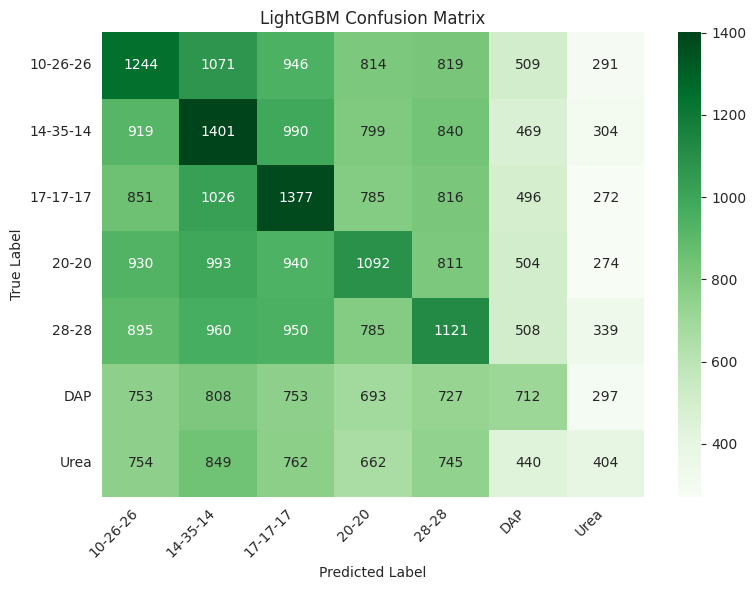

In [28]:
if 'lgbm_model' in locals() and 'X_train_smote' in locals() and 'y_train_smote' in locals():
    print("Training LightGBM model...")
    # Store training history for LightGBM
    evals_result_lgbm = {}
    lgbm_model.fit(X_train_smote, y_train_smote, 
                   eval_set=[(X_train_smote, y_train_smote), (X_test, y_test)], 
                   eval_names=['train', 'valid'],
                   callbacks=[
                       lgb.early_stopping(stopping_rounds=50, verbose=-1),
                       lgb.record_evaluation(evals_result_lgbm)
                   ])
    
    lgbm_model_path = os.path.join(model_dir, 'lightgbm_model.joblib')
    joblib.dump(lgbm_model, lgbm_model_path)
    print(f"LightGBM model trained and saved to: {lgbm_model_path}")

    # Evaluate LightGBM
    y_pred_lgbm = lgbm_model.predict(X_test)
    acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
    print(f"LightGBM Test Accuracy: {acc_lgbm:.4f}")
    
    # Calculate and store MAP@3 for LightGBM
    y_pred_proba_lgbm = lgbm_model.predict_proba(X_test)
    map3_lgbm = map_at_k(y_test, y_pred_proba_lgbm, k=3)
    model_map3_scores['LightGBM'] = map3_lgbm
    print(f"LightGBM MAP@3 Score: {map3_lgbm:.4f}")
    
    # Confusion Matrix for LightGBM
    print("\nConfusion Matrix for LightGBM:")
    if 'fertilizer_index_to_name_map' in locals():
        class_names_lgbm = [fertilizer_index_to_name_map[i] for i in sorted(fertilizer_index_to_name_map.keys())]
    else:
        class_names_lgbm = sorted(y_test.unique()) # Fallback
        
    cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=class_names_lgbm, 
                yticklabels=class_names_lgbm)
    plt.title('LightGBM Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping LightGBM training as model or data is not available.")

### 7.2 CatBoost Model

This cell sets up the CatBoost classifier with specified hyperparameters such as `iterations`, `learning_rate`, `depth`, and appropriate loss/evaluation metrics for multiclass classification. GPU usage is also configured based on the `USE_GPU` flag.

In [29]:
if 'X_train_smote' in locals() and 'y_train_smote' in locals():
    print("Configuring CatBoost model...")
    catboost_params = {
        'iterations': 5000,
        'learning_rate': 0.02,
        'depth': 8,
        'l2_leaf_reg': 3,
        'subsample': 0.8, 
        'random_seed': 42,
        'verbose': 0, 
        'early_stopping_rounds': 50,
        'bootstrap_type': 'Bernoulli' 
    }

    if USE_GPU:
        print("Configuring CatBoost for GPU.")
        catboost_params['task_type'] = 'GPU'
        # catboost_params['devices'] = '0' # Optional: specify GPU device if multiple are available
    else:
        print("Configuring CatBoost for CPU.")
        catboost_params['task_type'] = 'CPU'

    catboost_model = CatBoostClassifier(**catboost_params)
    print("CatBoost configured.")
else:
    print("Skipping CatBoost configuration as training data is not available.")

Configuring CatBoost model...
Configuring CatBoost for GPU.
CatBoost configured.


Training CatBoost model...
CatBoost model trained and saved to: model/catboost_model.joblib
CatBoost Test Accuracy: 0.1949
CatBoost MAP@3 Score: 0.3289

Confusion Matrix for CatBoost:


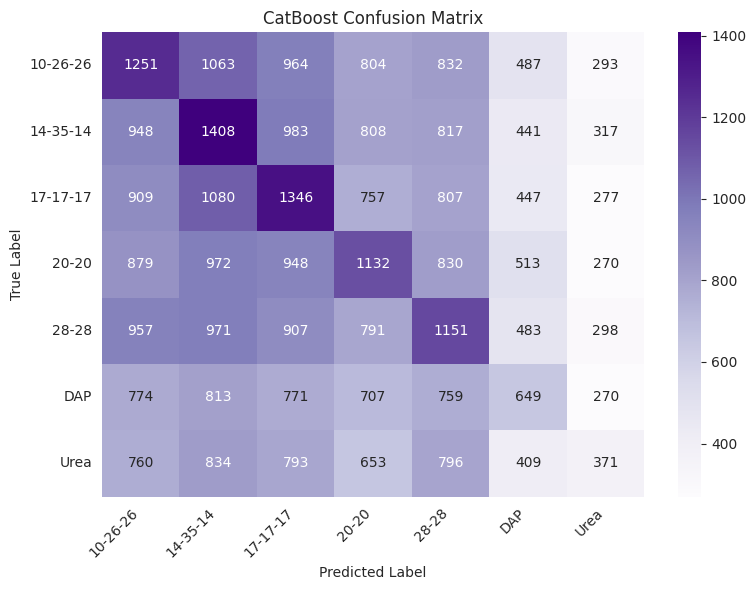

In [30]:
if 'catboost_model' in locals() and 'X_train_smote' in locals() and 'y_train_smote' in locals():
    print("Training CatBoost model...")
    
    # Corrected line: Provide only the test set for evaluation
    catboost_model.fit(X_train_smote, y_train_smote, 
                       eval_set=[(X_test, y_test)], # Only one dataset for GPU
                       verbose=0,
                      use_best_model=True) # It's good practice to set verbose to a number (e.g., 100) to see progress
    
    evals_result_catboost = catboost_model.get_evals_result()
    catboost_model_path = os.path.join(model_dir, 'catboost_model.joblib')
    joblib.dump(catboost_model, catboost_model_path)
    print(f"CatBoost model trained and saved to: {catboost_model_path}")

    # Evaluate CatBoost
    y_pred_catboost = catboost_model.predict(X_test)
    acc_catboost = accuracy_score(y_test, y_pred_catboost)
    print(f"CatBoost Test Accuracy: {acc_catboost:.4f}")
    
    # Calculate and store MAP@3 for CatBoost
    y_pred_proba_catboost = catboost_model.predict_proba(X_test)
    map3_catboost = map_at_k(y_test, y_pred_proba_catboost, k=3)
    model_map3_scores['CatBoost'] = map3_catboost
    print(f"CatBoost MAP@3 Score: {map3_catboost:.4f}")
    
    # Confusion Matrix for CatBoost
    print("\nConfusion Matrix for CatBoost:")
    if 'fertilizer_index_to_name_map' in locals():
        class_names_catboost = [fertilizer_index_to_name_map[i] for i in sorted(fertilizer_index_to_name_map.keys())]
    else:
        class_names_catboost = sorted(y_test.unique()) # Fallback
        
    cm_catboost = confusion_matrix(y_test, y_pred_catboost)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_catboost, annot=True, fmt='d', cmap='Purples', 
                xticklabels=class_names_catboost, 
                yticklabels=class_names_catboost)
    plt.title('CatBoost Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping CatBoost training as model or data is not available.")

### 7.3 XGBoost Model (for Ensemble)

We will now train the XGBoost classifier, which will also be part of our ensemble. It's trained on the SMOTE-augmented training data (`X_train_smote`, `y_train_smote`).

The XGBoost classifier is configured in the following cell. Key parameters include `objective` set to `multi:softmax` for multiclass classification, `num_class` for the number of target classes, and various regularization and tree-specific hyperparameters. Early stopping is also set up to prevent overfitting, and GPU usage is determined by the `USE_GPU` flag.

Configuring XGBoost for GPU.
Training XGBoost classifier with early stopping...

Training complete.
Best model (from early stopping) has 4999 boosting rounds.
XGBoost model (for ensemble) trained and saved to: model/xgboost_ensemble_model.joblib
XGBoost Test Accuracy (from training cell): 0.2015
XGBoost MAP@3 Score: 0.3374

Confusion Matrix for XGBoost


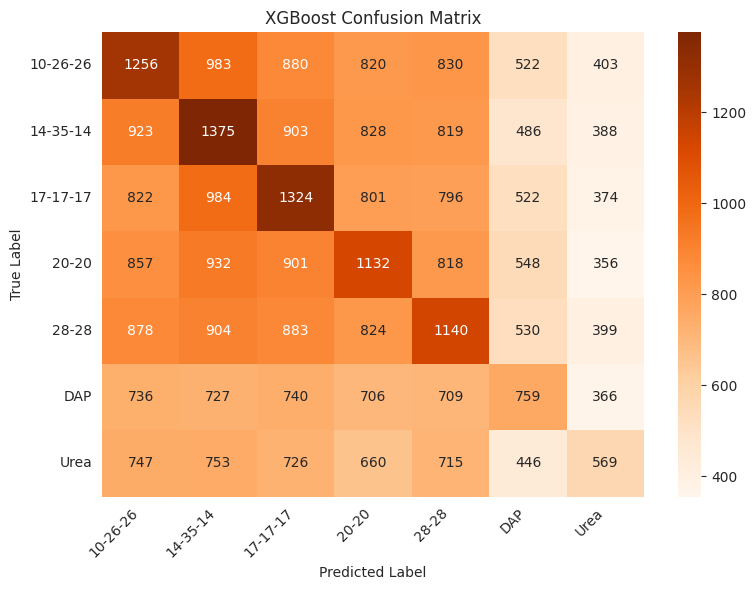

In [31]:
if 'X_train_smote' in locals() and 'y_train_smote' in locals():
    # Determine the number of unique classes for XGBoost's num_class parameter
    num_classes = y_train_smote.nunique()

    early_stopping_callback = xgb.callback.EarlyStopping(
        rounds=50,
        save_best=True,  # Saves the best model found during early stopping
        data_name='validation_0',
    )

    # Define a fixed set of best-known or trial parameters
    xgb_params = {
        'objective': 'multi:softmax',
        'num_class': num_classes,
        'eval_metric': 'mlogloss',
        'use_label_encoder': False,
        'n_estimators': 5000, # Simplified to match others for sample data
        'max_depth': 7,
        'learning_rate': 0.02, # Adjusted to be common
        'subsample': 0.7,
        'min_child_weight':3,
        'colsample_bytree': 0.8,
        'gamma': 0.1,
        'reg_alpha': 0.1,
        'reg_lambda': 1,
        'callbacks': [early_stopping_callback],
        'verbosity': 0,
        'random_state': 42
    }
    if USE_GPU:
        print("Configuring XGBoost for GPU.")
        xgb_params['tree_method'] = 'gpu_hist'
    else:
        print("Configuring XGBoost for CPU.")
        xgb_params['tree_method'] = 'hist' # or 'auto'
        
    xgb_classifier = xgb.XGBClassifier(**xgb_params)

    print("Training XGBoost classifier with early stopping...")
    xgb_classifier.fit(
        X_train_smote,
        y_train_smote,
        eval_set=[(X_train_smote, y_train_smote), (X_test, y_test)], # Added train set for history
        verbose=0  # Suppresses per-iteration logs
    )

    print("\nTraining complete.")
    evals_result_xgb = xgb_classifier.evals_result() # Store history
    print(f"Best model (from early stopping) has {xgb_classifier.best_iteration} boosting rounds.")

    # Save the trained XGBoost model for the ensemble
    xgb_model_path = os.path.join(model_dir, 'xgboost_ensemble_model.joblib') # model_dir defined in the previous cell
    joblib.dump(xgb_classifier, xgb_model_path)
    print(f"XGBoost model (for ensemble) trained and saved to: {xgb_model_path}")

    # Optionally evaluate here
    y_pred_xgb_train_cell = xgb_classifier.predict(X_test)
    acc_xgb_train_cell = accuracy_score(y_test, y_pred_xgb_train_cell)
    print(f"XGBoost Test Accuracy (from training cell): {acc_xgb_train_cell:.4f}")
    
    # Calculate and store MAP@3 for XGBoost
    y_pred_proba_xgb = xgb_classifier.predict_proba(X_test)
    map3_xgb = map_at_k(y_test, y_pred_proba_xgb, k=3)
    model_map3_scores['XGBoost'] = map3_xgb
    print(f"XGBoost MAP@3 Score: {map3_xgb:.4f}")

    # Confusion Matrix for XGBoost (from training cell)
    print("\nConfusion Matrix for XGBoost")
    if 'fertilizer_index_to_name_map' in locals():
        class_names_xgb = [fertilizer_index_to_name_map[i] for i in sorted(fertilizer_index_to_name_map.keys())]
    else:
        class_names_xgb = sorted(y_test.unique()) # Fallback
        
    cm_xgb_train_cell = confusion_matrix(y_test, y_pred_xgb_train_cell)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_xgb_train_cell, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=class_names_xgb, 
                yticklabels=class_names_xgb)
    plt.title('XGBoost Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("X_train_smote and/or y_train_smote are not defined. Skipping model training.")

### 7.4 Logistic Regression Model (Replaces Random Forest)

This section introduces the Logistic Regression classifier, which replaces the Random Forest model in the ensemble.

In [32]:
# This cell previously configured Random Forest. Now it's effectively replaced by the Logistic Regression configuration within the next cell (2b7bddb6).

In [33]:
if 'X_train_smote' in locals() and 'y_train_smote' in locals():
    print("Configuring and Training Logistic Regression model...")
    # Define Logistic Regression parameters
    lr_params = {
        "random_state": 42,
        "n_jobs": -1,                # Use all available cores
        "solver": "lbfgs",           # Default solver suitable for multiclass
        "max_iter": 2000,            # Increased max_iter for convergence, especially with SMOTE data
        "C": 1.0,                    # Default regularization strength
        "multi_class": "auto"        # Automatically selects ovr or multinomial based on solver
    }
    # Instantiate the Logistic Regression model
    lr_model = LogisticRegression(**lr_params)
    
    print("Training Logistic Regression model...")
    lr_model.fit(X_train_smote, y_train_smote)
    
    # Save the trained Logistic Regression model
    lr_model_path = os.path.join(model_dir, 'logistic_regression_model.joblib')
    joblib.dump(lr_model, lr_model_path)
    print(f"Logistic Regression model trained and saved to: {lr_model_path}")

    # Evaluate Logistic Regression
    y_pred_lr = lr_model.predict(X_test)
    acc_lr = accuracy_score(y_test, y_pred_lr)
    print(f"Logistic Regression Test Accuracy: {acc_lr:.4f}")
    
    # Calculate and store MAP@3 for Logistic Regression
    y_pred_proba_lr = lr_model.predict_proba(X_test)
    map3_lr = map_at_k(y_test, y_pred_proba_lr, k=3)
    model_map3_scores['LogisticRegression'] = map3_lr # Changed key from 'RandomForest'
    print(f"Logistic Regression MAP@3 Score: {map3_lr:.4f}")
    
    # Confusion Matrix for Logistic Regression
    print("\nConfusion Matrix for Logistic Regression:")
    if 'fertilizer_index_to_name_map' in locals():
        # Use a different variable name for class names to avoid potential conflicts if RF cell was just above
        class_names_for_lr_cm = [fertilizer_index_to_name_map[i] for i in sorted(fertilizer_index_to_name_map.keys())]
    else:
        class_names_for_lr_cm = sorted(y_test.unique()) # Fallback
        
    cm_lr = confusion_matrix(y_test, y_pred_lr)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Yellows', # Changed cmap for visual distinction from RF
                xticklabels=class_names_for_lr_cm, 
                yticklabels=class_names_for_lr_cm)
    plt.title('Logistic Regression Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    # Update the skip message
    print("Skipping Logistic Regression training as training data (X_train_smote, y_train_smote) is not available.")

Configuring and Training Logistic Regression model...
Training Logistic Regression model...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression model trained and saved to: model/logistic_regression_model.joblib
Logistic Regression Test Accuracy: 0.1485
Logistic Regression MAP@3 Score: 0.2694

Confusion Matrix for Logistic Regression:


KeyError: "'Yellows' is not a known colormap name"

<Figure size 800x600 with 0 Axes>

### 7.5 Plotting Model Training History

This section visualizes the training history (e.g., loss curves) for models where this information was captured. This helps in understanding if the models were prone to overfitting or if the training converged well.

In [ ]:
def plot_training_history(evals_result, model_name, metric='mlogloss'):
    if not evals_result:
        print(f"No training history found for {model_name}.")
        return
    
    plt.figure(figsize=(10, 6))
    
    # LightGBM stores history in a specific structure
    if model_name == 'LightGBM':
        if 'train' in evals_result and metric in evals_result['train']:
            plt.plot(evals_result['train'][metric], label=f'Train {metric}')
        if 'valid' in evals_result and metric in evals_result['valid']:
            plt.plot(evals_result['valid'][metric], label=f'Valid {metric}')
            
    # CatBoost also has its own structure
    elif model_name == 'CatBoost':
        # CatBoost eval_results are typically like: {'learn': {'MultiClass': [...]}, 'validation': {'MultiClass': [...]}}
        # The metric name might be 'MultiClass' or 'Logloss' or what was specified in 'eval_metric'
        train_metric_key = next(iter(evals_result.get('learn', {})), None)
        valid_metric_key = next(iter(evals_result.get('validation_0', {})), None) # Default eval set name
        if not valid_metric_key and 'validation' in evals_result: # Alternative if named 'validation'
             valid_metric_key = next(iter(evals_result.get('validation', {})), None)

        if train_metric_key and train_metric_key in evals_result.get('learn', {}):
            plt.plot(evals_result['learn'][train_metric_key], label=f'Train {train_metric_key}')
        if valid_metric_key and valid_metric_key in evals_result.get('validation_0', {}):
            plt.plot(evals_result['validation_0'][valid_metric_key], label=f'Valid {valid_metric_key}')
        elif valid_metric_key and valid_metric_key in evals_result.get('validation', {}):
             plt.plot(evals_result['validation'][valid_metric_key], label=f'Valid {valid_metric_key}')
            
    # XGBoost stores it as evals_result['validation_0']['mlogloss'] and evals_result['validation_1']['mlogloss']
    # if eval_set=[(X_train, y_train), (X_test, y_test)] was used.
    elif model_name == 'XGBoost':
        if 'validation_0' in evals_result and metric in evals_result['validation_0']:
            plt.plot(evals_result['validation_0'][metric], label=f'Train {metric}')
        if 'validation_1' in evals_result and metric in evals_result['validation_1']:
            plt.plot(evals_result['validation_1'][metric], label=f'Valid {metric}')
            
    else:
        print(f"Plotting logic not defined for {model_name}.")
        return

    plt.title(f'{model_name} Training History - {metric}')
    plt.xlabel('Iterations / Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot for LightGBM
if 'evals_result_lgbm' in locals():
    plot_training_history(evals_result_lgbm, 'LightGBM', metric='multi_logloss')
else:
    print("LightGBM training history not available.")

# Plot for CatBoost
if 'evals_result_catboost' in locals():
    # CatBoost default metric for MultiClass is 'MultiClass', or 'Logloss' if specified.
    # We'll try to plot 'MultiClass' or the first available metric if that's not present.
    catboost_metric_to_plot = 'MultiClass' 
    if not ('learn' in evals_result_catboost and catboost_metric_to_plot in evals_result_catboost['learn']):
        if 'learn' in evals_result_catboost and evals_result_catboost['learn']:
             catboost_metric_to_plot = next(iter(evals_result_catboost['learn']))
    plot_training_history(evals_result_catboost, 'CatBoost', metric=catboost_metric_to_plot)
else:
    print("CatBoost training history not available.")

# Plot for XGBoost
if 'evals_result_xgb' in locals():
    plot_training_history(evals_result_xgb, 'XGBoost', metric='mlogloss')
else:
    print("XGBoost training history not available.")

print("\nNote: LogisticRegression from scikit-learn does not provide a direct way to get per-iteration training history like boosting models.")

**Evaluation Observations:**
- **Accuracy:** The overall accuracy of the model on the test set will be noted here.
- **Classification Report:** 
    - *Precision*: Indicates the proportion of positive identifications that were actually correct. 
    - *Recall*: Indicates the proportion of actual positives that were correctly identified.
    - *F1-score*: A weighted average of precision and recall. 
    We will look at these scores for each fertilizer type to understand where the model performs well and where it might struggle.
- **Confusion Matrix:** This provides a visual representation of model performance, showing correct and incorrect predictions for each class. The diagonal elements represent the number of points for which the predicted label is equal to the true label, while off-diagonal elements are those that are mislabeled by the classifier.

## 8. Save Model and Artifacts

We will save the trained XGBoost model, the label encoder mapping (fertilizer name to index), and the list of feature names used during training. These are essential for making predictions on new data with the reusable class.

This cell handles the saving of crucial components for later use, especially by the `FertilizerPredictor` class:
1. **Models**: The individual trained models (LightGBM, CatBoost, XGBoost) have already been saved in their respective training cells within the `model/` directory.
2. **Label Map (`label_map.joblib`)**: The mapping from encoded label indices back to original fertilizer names (`fertilizer_index_to_name_map`) is saved. This is vital for interpreting the model's output.
3. **Feature Names (`feature_names.joblib`)**: The list of feature names (`feature_names`) that the models were trained on is saved. This ensures that any new data passed to the predictor can be processed and aligned to the same feature set.

All artifacts are saved into the `model/` directory.

In [ ]:
import os

# Define paths for saving artifacts
model_dir = 'model' # Path to the root 'model' directory
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Created directory: {model_dir}")

label_map_path = os.path.join(model_dir, 'label_map.joblib')
feature_names_path = os.path.join(model_dir, 'feature_names.joblib') # Or .json

try:
    # Save the fertilizer label map (index_to_name_map for easy decoding)
    if 'fertilizer_index_to_name_map' in locals():
        joblib.dump(fertilizer_index_to_name_map, label_map_path)
        print(f"Fertilizer label map saved to: {label_map_path}")
    else:
        print("Fertilizer label map ('fertilizer_index_to_name_map') not found. Cannot save.")
        
    # Save the list of feature names
    if 'feature_names' in locals():
        joblib.dump(feature_names, feature_names_path)
        print(f"Feature names saved to: {feature_names_path}")
    else:
        print("Feature names list ('feature_names') not found. Cannot save.")
    
    # Save the MAP@3 scores
    if 'model_map3_scores' in locals():
        map3_scores_path = os.path.join(model_dir, 'map3_scores.joblib')
        joblib.dump(model_map3_scores, map3_scores_path)
        print(f"MAP@3 scores saved to: {map3_scores_path}")
        print(f"MAP@3 Scores: {model_map3_scores}")
    else:
        print("MAP@3 scores ('model_map3_scores') not found. Cannot save.")
        
except Exception as e:
    print(f"Error saving artifacts: {e}")

The model, label map, and feature names are now saved and can be loaded by the prediction class.

## 9. Create Reusable Ensemble Prediction Class

Finally, we'll create a reusable Python class for making predictions using an ensemble of the trained models. This class will encapsulate all the necessary steps: loading the models and artifacts, preprocessing new input data, performing feature engineering, applying an ensemble strategy, and returning the predicted fertilizer name(s).

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
from scipy.stats import mode

class FertilizerPredictor:
    def __init__(self, model_dir='model', # Adjusted default model_dir
                 model_filenames=['lightgbm_model.joblib', 
                                  'catboost_model.joblib', 
                                  'xgboost_ensemble_model.joblib', 
                                  'logistic_regression_model.joblib']): # CHANGED HERE
        
        self.model_dir = model_dir
        self.model_filenames = model_filenames
        self.model_paths = [os.path.join(self.model_dir, fname) for fname in self.model_filenames]
        self.label_map_path = os.path.join(self.model_dir, 'label_map.joblib') 
        self.feature_names_path = os.path.join(self.model_dir, 'feature_names.joblib')
        self.map3_scores_path = os.path.join(self.model_dir, 'map3_scores.joblib')
        
        self.models = []
        self.model_names_for_scoring = [] # To store names like 'LightGBM', 'CatBoost' for map3_scores dict
        self.map3_scores = {}
        self.weights = []
        self.original_numerical_features = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']
        self.original_categorical_features = ['Soil Type', 'Crop Type']
        
        self._load_artifacts()

    def _load_artifacts(self):
        model_name_map = { 
            'lightgbm_model.joblib': 'LightGBM',
            'catboost_model.joblib': 'CatBoost',
            'xgboost_ensemble_model.joblib': 'XGBoost',
            'logistic_regression_model.joblib': 'LogisticRegression' # CHANGED HERE
        }
        try:
            for i, model_path in enumerate(self.model_paths):
                self.models.append(joblib.load(model_path))
                # Get the model name used as key in map3_scores dict
                model_filename = os.path.basename(model_path)
                self.model_names_for_scoring.append(model_name_map.get(model_filename, model_filename))
                
            self.index_to_name_map = joblib.load(self.label_map_path)
            self.trained_feature_names = joblib.load(self.feature_names_path)
            
            if os.path.exists(self.map3_scores_path):
                self.map3_scores = joblib.load(self.map3_scores_path)
                print(f"MAP@3 scores loaded: {self.map3_scores}")
            else:
                print(f"Warning: MAP@3 scores file not found at {self.map3_scores_path}. Using uniform weights.")
                # Assign uniform scores if file not found, leading to uniform weights
                for model_key in self.model_names_for_scoring:
                    self.map3_scores[model_key] = 1.0 / len(self.models) if len(self.models) > 0 else 1.0

            # Calculate weights based on MAP@3 scores
            loaded_model_scores = []
            for name in self.model_names_for_scoring:
                score = self.map3_scores.get(name)
                if score is None:
                    print(f"Warning: MAP@3 score for model '{name}' not found. Assigning a default low score (0.01) for weight calculation.")
                    score = 0.01 # Assign a small score to avoid zero division and ensure it gets a low weight
                loaded_model_scores.append(score)
            
            total_score = sum(loaded_model_scores)
            if total_score > 0:
                self.weights = [score / total_score for score in loaded_model_scores]
            else: # If all scores are 0 or very low, use uniform weights
                print("Warning: All MAP@3 scores are zero or invalid. Using uniform weights.")
                self.weights = [1.0 / len(self.models) if len(self.models) > 0 else 1.0] * len(self.models)
            
            print(f"{len(self.models)} models, artifacts, and weights loaded successfully.")
            print(f"Model weights for ensemble: {self.weights}")

        except FileNotFoundError as e:
            print(f"Error loading artifacts: {e}. Ensure models and artifacts are in specified paths.")
            self.models = []
            self.index_to_name_map = None
            self.trained_feature_names = None
            self.map3_scores = {}
            self.weights = []
        except Exception as e:
            print(f"An unexpected error occurred while loading artifacts: {e}")
            self.models = []
            self.index_to_name_map = None
            self.trained_feature_names = None
            self.map3_scores = {}
            self.weights = []

    def _preprocess_input(self, input_data):
        if not isinstance(input_data, pd.DataFrame):
            input_df = pd.DataFrame([input_data])
        else:
            input_df = input_data.copy()
        
        if 'Humidity ' in input_df.columns:
            input_df.rename(columns={'Humidity ': 'Humidity'}, inplace=True)

        for col in self.original_categorical_features:
            if col in input_df.columns:
                input_df[col] = input_df[col].astype('category')
        
        input_df_encoded = pd.get_dummies(input_df, columns=self.original_categorical_features, prefix=self.original_categorical_features, dtype=int)
        return input_df_encoded

    def _engineer_features(self, input_df):
        df_eng = input_df.copy()
        epsilon = 1e-6
        if 'Nitrogen' in df_eng.columns and 'Phosphorous' in df_eng.columns:
            df_eng['N_P_ratio'] = df_eng['Nitrogen'] / (df_eng['Phosphorous'] + epsilon)
        if 'Nitrogen' in df_eng.columns and 'Potassium' in df_eng.columns:
            df_eng['N_K_ratio'] = df_eng['Nitrogen'] / (df_eng['Potassium'] + epsilon)
        if 'Phosphorous' in df_eng.columns and 'Potassium' in df_eng.columns:
            df_eng['P_K_ratio'] = df_eng['Phosphorous'] / (df_eng['Potassium'] + epsilon)
        if 'Temparature' in df_eng.columns and 'Humidity' in df_eng.columns:
            df_eng['Temp_Hum_Interaction'] = df_eng['Temparature'] * df_eng['Humidity']
        if 'Temparature' in df_eng.columns and 'Moisture' in df_eng.columns:
            df_eng['Moisture_Temp_Interaction'] = df_eng['Moisture'] * df_eng['Temparature']
        for col in self.original_numerical_features:
            if col in df_eng.columns:
                df_eng[f'log_{col}'] = np.log1p(df_eng[col])
                df_eng[f'sq_{col}'] = df_eng[col]**2
        return df_eng

    def _align_features(self, input_df_engineered):
        aligned_df = pd.DataFrame(columns=self.trained_feature_names)
        for col in self.trained_feature_names:
            if col in input_df_engineered.columns:
                aligned_df[col] = input_df_engineered[col]
            else:
                aligned_df[col] = 0 
        return aligned_df[self.trained_feature_names]

    def predict(self, input_data, strategy='hard_voting'):
        if not self.models or self.index_to_name_map is None or self.trained_feature_names is None:
            print("Predictor not initialized properly or no models loaded. Cannot predict.")
            return None

        processed_df = self._preprocess_input(input_data)
        engineered_df = self._engineer_features(processed_df)
        final_df = self._align_features(engineered_df)

        try:
            if strategy == 'hard_voting':
                all_predictions = []
                for model in self.models:
                    # Ensure predictions are always 1D for individual samples or 2D for batch
                    pred = model.predict(final_df)
                    if pred.ndim == 0: # Handle scalar prediction for single input
                        pred = np.array([pred])
                    elif pred.ndim == 2 and pred.shape[1] == 1: # Handle (N, 1) predictions
                         pred = pred.flatten()
                    all_predictions.append(pred)

                # Stack predictions. Transpose if needed so that each row is a sample and columns are model predictions.
                # Then take mode along axis 0 to get the most frequent prediction for each sample.
                all_predictions_stacked = np.array(all_predictions)
                
                # If there's only one sample, mode might return a scalar. Ensure it's an array.
                ensemble_prediction_encoded, _ = mode(all_predictions_stacked, axis=0, keepdims=False)

                if not isinstance(ensemble_prediction_encoded, np.ndarray):
                    ensemble_prediction_encoded = np.array([ensemble_prediction_encoded])

            elif strategy == 'soft_voting':
                all_proba_predictions = []
                for model in self.models:
                    if hasattr(model, 'predict_proba'):
                        proba = model.predict_proba(final_df)
                        all_proba_predictions.append(proba)
                    else:
                        # Fallback for models without predict_proba: one-hot encode predictions
                        num_classes = len(self.index_to_name_map)
                        predictions = model.predict(final_df)
                        # Ensure predictions is an array for consistent indexing
                        if predictions.ndim == 0:
                            predictions = np.array([predictions])
                        elif predictions.ndim == 2 and predictions.shape[1] == 1:
                            predictions = predictions.flatten()

                        proba_like = np.zeros((final_df.shape[0], num_classes))
                        for i, pred_class_val in enumerate(predictions):
                            # Ensure pred_class_val is an integer and valid index
                            if isinstance(pred_class_val, (np.integer, int)) and 0 <= pred_class_val < num_classes:
                                proba_like[i, pred_class_val] = 1.0
                            else:
                                print(f"Warning: Model predicted {pred_class_val} which is not a valid class index. Skipping.")
                        all_proba_predictions.append(proba_like)


                avg_proba = np.mean(np.array(all_proba_predictions), axis=0)
                ensemble_prediction_encoded = np.argmax(avg_proba, axis=1)

            else:
                raise ValueError("Unsupported voting strategy. Choose 'hard_voting' or 'soft_voting'.")

            predicted_fertilizer_names = [self.index_to_name_map.get(pred_code, "Unknown") for pred_code in ensemble_prediction_encoded]

            return predicted_fertilizer_names[0] if len(predicted_fertilizer_names) == 1 and not isinstance(input_data, pd.DataFrame) else predicted_fertilizer_names
        except Exception as e:
            print(f"Error during ensemble prediction: {e}")
            print("Input data after processing and engineering leading to error:")
            print(final_df.head())
            print(f"Expected columns: {self.trained_feature_names}")
            return None
        
    def predict_proba(self, input_data):
        if not self.models or self.trained_feature_names is None:
            print("Predictor not initialized properly or no models loaded. Cannot predict probabilities.")
            return None
        
        processed_df = self._preprocess_input(input_data)
        engineered_df = self._engineer_features(processed_df)
        final_df = self._align_features(engineered_df)
        
        try:
            weighted_probas_list = []
            if not self.weights or len(self.weights) != len(self.models):
                print("Warning: Weights not properly initialized or length mismatch. Using uniform weighting for predict_proba.")
                current_weights = [1.0 / len(self.models)] * len(self.models) if len(self.models) > 0 else []
            else:
                current_weights = self.weights

            for i, model in enumerate(self.models):
                weight = current_weights[i] if i < len(current_weights) else (1.0 / len(self.models) if len(self.models) > 0 else 0)
                if hasattr(model, 'predict_proba'):
                    proba = model.predict_proba(final_df)
                    weighted_probas_list.append(proba * weight)
                else:
                    num_classes = len(self.index_to_name_map)
                    predictions = model.predict(final_df)
                    proba_like = np.zeros((final_df.shape[0], num_classes))
                    for j, pred_class in enumerate(predictions):
                        proba_like[j, pred_class] = 1.0
                    weighted_probas_list.append(proba_like * weight)
            
            if not weighted_probas_list:
                return np.array([]) # Return empty array if no probabilities were generated
                
            # Summing weighted probabilities. Since weights sum to 1 (or should, if normalized correctly),
            # this directly gives the weighted average probability distribution.
            sum_weighted_probas = np.sum(np.array(weighted_probas_list), axis=0)
            return sum_weighted_probas
            
        except Exception as e:
            print(f"Error during weighted ensemble probability prediction: {e}")
            return None
            
    def predict_top_n(self, input_data, n=3):
        probabilities = self.predict_proba(input_data)
        if probabilities is None:
            return None
        
        # Ensure probabilities is a 2D array
        if probabilities.ndim == 1:
            probabilities = probabilities.reshape(1, -1)
            
        top_n_indices = np.argsort(probabilities, axis=1)[:, -n:][:, ::-1]
        top_n_fertilizers = []
        for indices_row in top_n_indices:
            fertilizers_row = [self.index_to_name_map.get(idx, "Unknown") for idx in indices_row]
            top_n_fertilizers.append(fertilizers_row)
            
        if not isinstance(input_data, pd.DataFrame) or (isinstance(input_data, pd.DataFrame) and len(input_data) == 1):
            return top_n_fertilizers[0] if top_n_fertilizers else [] 
        return top_n_fertilizers


### 9.1 Testing the `FertilizerPredictor` Class

Let's instantiate the class and test it with a sample input. The sample input should be a dictionary or a Pandas DataFrame with the raw feature names.

In [ ]:
# Test the FertilizerPredictor class
model_files = [
    'lightgbm_model.joblib',
    'catboost_model.joblib',
    'xgboost_ensemble_model.joblib',
    'logistic_regression_model.joblib' # CHANGED HERE
]
predictor_test_instance = FertilizerPredictor(model_dir='model', model_filenames=model_files)

if predictor_test_instance.models: # Check if artifacts loaded successfully
    # Sample input 1 (dictionary)
    sample_input_1 = {
        'Temparature': 28, 
        'Humidity': 55, 
        'Moisture': 40,
        'Soil Type': 'Clayey',
        'Crop Type': 'Wheat',
        'Nitrogen': 50,
        'Potassium': 30,
        'Phosphorous': 60
    }
    
    print("\n--- Testing Single Prediction (Hard Voting) ---")
    predicted_fertilizer_1_hard = predictor_test_instance.predict(sample_input_1, strategy='hard_voting')
    print(f"Prediction for Sample Input 1 (Hard Voting): {predicted_fertilizer_1_hard}")

    print("\n--- Testing Single Prediction (Soft Voting) ---")
    predicted_fertilizer_1_soft = predictor_test_instance.predict(sample_input_1, strategy='soft_voting')
    print(f"Prediction for Sample Input 1 (Soft Voting): {predicted_fertilizer_1_soft}")

    # Sample input 2 (DataFrame for batch prediction)
    sample_input_2_df = pd.DataFrame([
        {
            'Temparature': 34, 'Humidity': 65, 'Moisture': 45, 
            'Soil Type': 'Red', 'Crop Type': 'Ground Nuts', 
            'Nitrogen': 20, 'Potassium': 10, 'Phosphorous': 30
        },
        {
            'Temparature': 25, 'Humidity': 60, 'Moisture': 50, 
            'Soil Type': 'Sandy', 'Crop Type': 'Barley', 
            'Nitrogen': 70, 'Potassium': 40, 'Phosphorous': 20
        }
    ])
    print("\n--- Testing Batch Prediction (Hard Voting) ---")
    predicted_fertilizers_2_hard = predictor_test_instance.predict(sample_input_2_df, strategy='hard_voting')
    print(f"Predictions for Sample Input 2 (Hard Voting): {predicted_fertilizers_2_hard}")

    print("\n--- Testing Batch Prediction (Soft Voting) ---")
    predicted_fertilizers_2_soft = predictor_test_instance.predict(sample_input_2_df, strategy='soft_voting')
    print(f"Predictions for Sample Input 2 (Soft Voting): {predicted_fertilizers_2_soft}")
    
    print("\n--- Testing Top-N Predictions ---")
    top_n_fertilizers_1 = predictor_test_instance.predict_top_n(sample_input_1, n=3)
    print(f"Top 3 predictions for Sample Input 1: {top_n_fertilizers_1}")

    top_n_fertilizers_2 = predictor_test_instance.predict_top_n(sample_input_2_df, n=3)
    print(f"Top 3 predictions for Sample Input 2 (DataFrame): {top_n_fertilizers_2}")

    # Test with a known entry from the original dataset (e.g., first row)
    if not df.empty:
        print("\n--- Testing with the first row of the original dataset (Hard Voting) ---")
        first_row_original_df = df.iloc[[0]] 
        
        # Prepare input by dropping target columns if they exist (they would if df is from train.csv)
        first_row_input = first_row_original_df.drop(columns=['Fertilizer Name', 'Fertilizer Name_Encoded'], errors='ignore')
        
        prediction_first_row = predictor_test_instance.predict(first_row_input, strategy='hard_voting')
        print(f"Input data for first row:\n{first_row_input.to_dict(orient='records')[0]}")
        print(f"Predicted Fertilizer for first row (Hard Voting): {prediction_first_row}")
        if 'Fertilizer Name' in first_row_original_df.columns:
             print(f"Actual Fertilizer for first row: {first_row_original_df['Fertilizer Name'].iloc[0]}")
else:
    print("Predictor could not be initialized or models not loaded. Skipping tests.")

## 10. Generate Submission File using Ensemble Predictions

In this section, we will:
1. Load the `test.csv` data.
2. Use the updated `FertilizerPredictor`'s `predict_top_n` method (which internally uses the ensemble) to get the top 3 fertilizer predictions for each entry.
3. Format these predictions into a `submission.csv` file.

### 10.1 Load Test Data

In [ ]:
test_data_path = '/kaggle/input/playground-series-s5e6/test.csv' 
try:
    test_df = pd.read_csv(test_data_path)
    print(f"Test data loaded successfully from {test_data_path}")
    display(test_df.head())
    print("Test data information:")
    test_df.info()
except FileNotFoundError:
    print(f"Error: {test_data_path} not found. Please ensure the test file exists.")
    test_df = pd.DataFrame() 

### 10.2 Get Top 3 Predictions for Test Data

In [ ]:
# Instantiate the predictor for submission, ensuring it uses the ensemble models
model_files_for_submission = [
    'lightgbm_model.joblib',
    'catboost_model.joblib',
    'xgboost_ensemble_model.joblib',
    'logistic_regression_model.joblib' # CHANGED HERE
]
submission_predictor = FertilizerPredictor(model_dir='model', model_filenames=model_files_for_submission)

if not test_df.empty and submission_predictor.models: # Check if predictor.models is not empty
    print("Generating top 3 predictions for the test data using ensemble...")
    
    test_features_df = test_df.drop(columns=['id'], errors='ignore') 
    
    if 'Humidity ' in test_features_df.columns:
        test_features_df.rename(columns={'Humidity ': 'Humidity'}, inplace=True)
        print("Renamed 'Humidity ' to 'Humidity' in test data.")
        
    top_3_predictions_list = submission_predictor.predict_top_n(test_features_df, n=3)
    
    if top_3_predictions_list:
        print(f"Generated {len(top_3_predictions_list)} top 3 predictions.")
        for i in range(min(5, len(top_3_predictions_list))):
            print(f"ID {test_df['id'].iloc[i] if 'id' in test_df.columns else i}: {top_3_predictions_list[i]}")
        
        submission_fertilizer_names = [' '.join(preds) for preds in top_3_predictions_list]
    else:
        print("Failed to generate top 3 predictions.")
        submission_fertilizer_names = []
else:
    print("Test data is empty or predictor is not initialized with models. Skipping top-3 prediction generation.")
    submission_fertilizer_names = []

### 10.3 Create and Save Submission File

In [ ]:
if not test_df.empty and submission_fertilizer_names and len(test_df) == len(submission_fertilizer_names):
    submission_df = pd.DataFrame({
        'id': test_df['id'],
        'Fertilizer Name': submission_fertilizer_names
    })
    
    submission_file_path = 'submission.csv' 

    try:
        submission_df.to_csv(submission_file_path, index=False)
        print(f"\nSubmission file created successfully at: {submission_file_path}")
        display(submission_df.head())
    except Exception as e:
        print(f"Error saving submission file: {e}")
        
elif test_df.empty:
    print("Test data was not loaded. Cannot create submission file.")
elif not submission_fertilizer_names:
    print("Submission fertilizer names were not generated. Cannot create submission file.")
else:
    print("Mismatch between length of test data IDs and predictions. Cannot create submission file.")

## 11. Prediction on Custom Test Data and Evaluation

This section handles prediction on a new dataset (`/kaggle/input/fertilizer-prediction/Fertilizer Prediction.csv`). We will load this data, make predictions using our ensemble `FertilizerPredictor`, save these predictions, and then evaluate the performance using a confusion matrix since this dataset contains the target variable 'Fertilizer Name'.

### 11.1 Load Custom Test Data

In [ ]:
custom_test_data_path = '/kaggle/input/fertilizer-prediction/Fertilizer Prediction.csv'
new_test_df = pd.DataFrame() # Initialize an empty DataFrame
try:
    new_test_df = pd.read_csv(custom_test_data_path)
    print(f"Custom test data loaded successfully from {custom_test_data_path}")
    display(new_test_df.head())
    print("Custom test data information:")
    new_test_df.info()
    # Check for 'Fertilizer Name' which is needed for CM
    if 'Fertilizer Name' not in new_test_df.columns:
        print("Warning: Target column 'Fertilizer Name' not found in the custom test data. Confusion matrix cannot be plotted.")
except FileNotFoundError:
    print(f"Error: {custom_test_data_path} not found. Please ensure the file exists.")
except Exception as e:
    print(f"An error occurred while loading the custom test data: {e}")

### 11.2 Make Predictions on Custom Test Data

In [ ]:
if not new_test_df.empty and 'Fertilizer Name' in new_test_df.columns:
    # Ensure the predictor instance is available. 
    # If this notebook is run top-to-bottom, `submission_predictor` or `predictor_test_instance` should exist.
    # Let's use `submission_predictor` as it was intended for general prediction tasks.
    # If it's not defined, we might need to re-initialize it or ensure the cell defining it has been run.
    if 'submission_predictor' not in locals() or not submission_predictor.models:
        print("Re-initializing FertilizerPredictor for custom test data...")
        # Ensure all models, including Random Forest, are part of the ensemble for custom test evaluation
        model_files_for_custom_test = [
            'lightgbm_model.joblib',
            'catboost_model.joblib',
            'xgboost_ensemble_model.joblib',
            'logistic_regression_model.joblib' # CHANGED HERE
        ]
        # Make sure the 'model_dir' and 'FertilizerPredictor' class definition are accessible
        # This assumes 'model_dir' is 'model' and FertilizerPredictor class is defined above
        try:
            custom_predictor = FertilizerPredictor(model_dir='model', model_filenames=model_files_for_custom_test)
        except NameError:
            print("Error: FertilizerPredictor class definition not found. Ensure it's defined earlier in the notebook.")
            custom_predictor = None # Set to None to prevent further errors
    else:
        custom_predictor = submission_predictor # Use the existing predictor

    if custom_predictor and custom_predictor.models:
        print("Preparing custom test data for prediction...")
        custom_test_features = new_test_df.copy()
        
        # Store Id column if it exists, then drop it for prediction
        custom_test_ids = None
        if 'Id' in custom_test_features.columns:
            custom_test_ids = custom_test_features['Id']
            custom_test_features = custom_test_features.drop(columns=['Id'])
            print("Dropped 'Id' column for prediction.")
        elif 'ID' in custom_test_features.columns: # Handle 'ID' as well
            custom_test_ids = custom_test_features['ID']
            custom_test_features = custom_test_features.drop(columns=['ID'])
            print("Dropped 'ID' column for prediction.")

        # Separate true labels for CM later, and drop from features for prediction
        custom_test_true_labels_str = custom_test_features['Fertilizer Name']
        custom_test_features_for_prediction = custom_test_features.drop(columns=['Fertilizer Name'])
        
        print("Generating predictions for the custom test data...")
        # Using 'hard_voting' as an example, can be changed to 'soft_voting'
        custom_test_predictions_list = custom_predictor.predict_top_n(custom_test_features_for_prediction, n=1)
        
        if custom_test_predictions_list:
            print(f"Generated {len(custom_test_predictions_list)} predictions.")
            # Display a few predictions
            for i in range(min(5, len(custom_test_predictions_list))):
                row_id = custom_test_ids.iloc[i] if custom_test_ids is not None else f"Row {i}"
                print(f"{row_id}: Predicted: {custom_test_predictions_list[i]}, Actual: {custom_test_true_labels_str.iloc[i]}")
            
            # Create a submission-like file for these predictions
            results_df = pd.DataFrame()
            if custom_test_ids is not None:
                results_df['Id'] = custom_test_ids
            else:
                results_df['Row_Index'] = custom_test_features_for_prediction.index
                
            results_df['Fertilizer_Name_Predicted'] = custom_test_predictions_list
            results_df['Fertilizer_Name_Actual'] = custom_test_true_labels_str.values # Ensure alignment
            
            custom_submission_file_path = 'custom_test_predictions.csv'
            try:
                results_df.to_csv(custom_submission_file_path, index=False)
                print(f"\nCustom test predictions saved to: {custom_submission_file_path}")
                display(results_df.head())
            except Exception as e:
                print(f"Error saving custom test predictions file: {e}")
        else:
            print("Failed to generate predictions for custom test data.")
    else:
        print("Predictor for custom test data is not available or not loaded with models. Skipping prediction.")
elif new_test_df.empty:
    print("Custom test data is empty. Skipping prediction.")
else: # 'Fertilizer Name' not in new_test_df.columns
    print("Target 'Fertilizer Name' not in custom_test_df. Cannot proceed with this prediction and CM block as designed.")

### 11.3 Confusion Matrix for Custom Test Data Predictions

Now we'll visualize the performance of our ensemble model on the custom test dataset using a confusion matrix. This requires the true labels (`custom_test_true_labels_str`) and the predicted labels (`custom_test_predictions_list`) from the previous step.

In [ ]:
if 'custom_test_true_labels_str' in locals() and 'custom_test_predictions_list' in locals() and custom_test_predictions_list is not None:
    if len(custom_test_true_labels_str) == len(custom_test_predictions_list):
        print("Plotting Confusion Matrix for custom test data...")
        
        # Ensure target_encoder is available and fitted, or use the map from the predictor
        # The `FertilizerPredictor` loads `index_to_name_map`. We can derive sorted class names from this.
        if custom_predictor and custom_predictor.index_to_name_map:
            # Sort class names based on their encoded index to ensure consistency
            sorted_class_names = [custom_predictor.index_to_name_map[i] for i in sorted(custom_predictor.index_to_name_map.keys())]
        elif 'target_encoder' in locals() and hasattr(target_encoder, 'classes_'):
            sorted_class_names = list(target_encoder.classes_)
        else:
            # Fallback: derive from unique values, order might not be guaranteed optimal for display
            sorted_class_names = sorted(list(set(custom_test_true_labels_str) | set(custom_test_predictions_list)))
            print("Warning: Using fallback for class names order in CM. Ensure 'target_encoder' or 'custom_predictor.index_to_name_map' is properly initialized for consistent label ordering.")

        cm_custom_test = confusion_matrix(custom_test_true_labels_str, custom_test_predictions_list, labels=sorted_class_names)
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm_custom_test, annot=True, fmt='d', cmap='Blues',
                    xticklabels=sorted_class_names, yticklabels=sorted_class_names)
        plt.title('Confusion Matrix for Custom Test Data (Ensemble Predictions)')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        # Optional: Print classification report
        print("\nClassification Report for Custom Test Data:")
        print(classification_report(custom_test_true_labels_str, custom_test_predictions_list, labels=sorted_class_names, zero_division=0))

    else:
        print("Mismatch in length between true labels and predictions for custom test data. Cannot plot CM.")
else:
    print("True labels or predictions for custom test data are not available. Skipping Confusion Matrix plotting.")